
# PINN - Caso BFS Driver & Seegmiller

In [51]:
# Inicializa as bibliotecas necessárias
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# Define os caminhos dos diretórios
PATH_DIR = Path.cwd().parent  # diretório atual
PATH_CFD = PATH_DIR / 'cfd_bfs_2d' # diretório dos dados CFD
PATH_DATA = PATH_DIR / 'data' # diretório para salvar os dados processados
PATH_OUT = PATH_DIR / 'results' # diretório para salvar os resultados e plotagens
PATH_MODEL = PATH_OUT / 'models' # diretório para salvar o modelo treinado
print(PATH_DIR)
print(PATH_CFD)
print(PATH_DATA)
print(PATH_OUT)
print(PATH_MODEL)

/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller/cfd_bfs_2d
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller/data
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller/results
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller/results/models


## Preparando Dataset dos dados CFD
- Aqui preparamos o dataset que será utilizado no treinamento da PINN, com a diferença entre a malha coarse(grosseira) e a fine(refinada), para que assim a rede aprenda justamente a correção delta.

In [2]:
# -------------------------------------------------
# Utilidades
# -------------------------------------------------

def latest_dir(base: Path) -> Path:
    """Retorna o diretório do último 'tempo'."""
    times = sorted(
        [p for p in base.iterdir() if p.is_dir()],
        key=lambda p: float(p.name)
    )
    return times[-1]


def read_grid_file(path: Path) -> pd.DataFrame:
    """
    Lê o arquivo grid_pinn_epsilon_k_nut_p_U.xy no formato:
    x y z epsilon k nut p Ux Uy Uz
    """
    rows = []
    num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or line.startswith("//"):
                continue

            nums = num_re.findall(line)
            if len(nums) < 10:
                continue

            x, y, z, epsilon, k, nut, p, ux, uy, uz = map(float, nums[:10])
            rows.append((x, y, z, epsilon, k, nut, p, ux, uy, uz))

    return pd.DataFrame(
        rows, columns=["x", "y", "z", "epsilon", "k", "nut", "p", "Ux", "Uy", "Uz"]
    )


def load_case(case_dir: str) -> pd.DataFrame:
    """
    Carrega o grid_pinn_epsilon_k_nut_p_U.xy do último tempo do caso.
    """
    case = Path(case_dir)
    base = case / "postProcessing" / "sample_pinn"
    tdir = latest_dir(base)

    fpath = tdir / "grid_pinn_epsilon_k_nut_p_U.xy"
    if not fpath.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {fpath}")

    return read_grid_file(fpath)

# -------------------------------------------------
# Main
# -------------------------------------------------

print("Lendo caso coarse...")
dfc = load_case(PATH_CFD / "bfs_2d_coarse")

print("Lendo caso fine...")
dff = load_case(PATH_CFD / "bfs_2d_fine")

# Merge ponto a ponto (x,y)
df = dfc.merge(
    dff[["x", "y", "epsilon", "k", "nut", "p", "Ux", "Uy"]].rename(
        columns={
            "p": "p_f",
            "Ux": "Ux_f",
            "Uy": "Uy_f",
            "epsilon": "epsilon_f",
            "k": "k_f",
            "nut": "nut_f"
        }
    ),
    on=["x", "y"],
    how="inner"
)

# Erro coarse -> fine (targets do ML)
df["dUx"] = df["Ux_f"] - df["Ux"]
df["dUy"] = df["Uy_f"] - df["Uy"]
df["dp"]  = df["p_f"]  - df["p"]
df["depsilon"] = df["epsilon_f"] - df["epsilon"]
df["dk"] = df["k_f"] - df["k"]
df["dnut"] = df["nut_f"] - df["nut"]
df["log_nut"] = np.log10(df["nut"] + 1e-12)  # log(nut) para ML

# Reynolds (fixo neste experimento)
df["Re"] = 36000.0

# Dataset final
out = df[[
    "x", "y",
    "Ux", "Uy", "p", "epsilon", "k", "log_nut",
    "Re",
    "dUx", "dUy", "dp", "depsilon", "dk", "dnut"
]].copy()
out_name = "dataset_bfs_2d_kepsilon.parquet"
out.to_parquet(PATH_DATA / out_name, index=False)
print(f"Dataset salvo em: {out_name}")
print("Total de amostras:", len(out))

Lendo caso coarse...
Lendo caso fine...
Dataset salvo em: dataset_bfs_2d_kepsilon.parquet
Total de amostras: 100975


In [3]:
df=pd.read_parquet(PATH_DATA / "dataset_bfs_2d_kepsilon.parquet")
df.head()

,x,y,Ux,Uy,p,epsilon,k,log_nut,Re,dUx,dUy,dp,depsilon,dk,dnut
0,0.002800,0.0,0.0,0.0,16.30860,126644.0,1.46918,-1.561923,36000.0,0.0,0.0,-654.40860,-9.929130e+04,-1.250487,-0.025904
1,0.007381,0.0,0.0,0.0,3.10882,564753.0,4.05172,-9.045664,36000.0,0.0,0.0,-661.40682,2.086070e+05,-2.010220,0.002724
2,0.011962,0.0,0.0,0.0,7.10518,811732.0,5.09731,-2.230671,36000.0,0.0,0.0,-670.99518,1.382518e+06,-1.004610,-0.005241
3,0.016543,0.0,0.0,0.0,39.53730,159728000.0,138.11800,-2.548872,36000.0,0.0,0.0,-689.56030,-1.597215e+08,-138.035866,-0.001307
4,0.021124,0.0,0.0,0.0,83.79700,256150.0,2.38642,-2.888029,36000.0,0.0,0.0,-753.86000,-2.523631e+05,-2.328312,-0.000018


In [4]:
df.describe()

,x,y,Ux,Uy,p,epsilon,k,log_nut,Re,dUx,dUy,dp,depsilon,dk,dnut
count,100975.000000,100975.000000,100975.000000,100975.000000,100975.000000,1.009750e+05,1.009750e+05,100975.000000,100975.0,100975.000000,100975.000000,100975.000000,1.009750e+05,100975.000000,1.009750e+05
mean,-0.479543,0.061698,42.554235,-0.110870,132.558009,1.914596e+04,1.103570e+01,-5.158847,36000.0,0.037372,-0.001901,-68.738597,6.348742e+04,0.124928,-2.256255e-03
std,0.667885,0.030716,8.310754,0.624127,71.387386,6.533074e+05,1.919407e+01,3.499228,0.0,8.851780,4.001391,338.152735,7.097039e+06,26.687948,8.090819e-03
min,-1.651000,0.000000,-12.701400,-5.877700,-83.634600,8.762990e-08,1.243070e-09,-11.602105,36000.0,-63.255400,-36.210663,-2376.377700,-1.597215e+08,-138.035866,-4.021881e-02
25%,-1.060030,0.035490,41.382900,-0.067909,77.818300,2.420570e-02,7.637845e-05,-8.391590,36000.0,-2.222150,-0.518783,-329.038100,-1.111784e+02,-2.747479,-1.923299e-03
50%,-0.469060,0.062108,45.445200,-0.002989,118.866000,9.633100e+01,8.828560e-01,-3.275329,36000.0,0.822600,-0.002637,-1.195000,-1.921661e-04,-0.000002,-1.221755e-09
75%,0.112747,0.088204,47.220900,0.057166,185.413500,3.348915e+03,1.329345e+01,-2.336258,36000.0,3.117400,0.496151,236.246000,1.107007e+03,2.122057,1.747002e-04
max,0.635000,0.114300,51.277500,4.283060,276.816000,1.597280e+08,1.381180e+02,-1.390376,36000.0,38.851900,42.526200,356.641000,1.640644e+09,426.098400,8.091608e-02


In [6]:
df.nlargest(20, "epsilon")[["x","y","epsilon","k","nut"]]

,x,y,epsilon,k,nut
3,0.016543,0.0000,159728000.0,138.1180,2.825710e-03
11,0.053192,0.0000,120263000.0,130.4700,1.525560e-03
100886,0.231858,0.1143,6788060.0,22.3883,1.180040e-05
100885,0.227277,0.1143,6625730.0,21.9672,1.153550e-05
100884,0.222695,0.1143,6463400.0,21.5462,1.127060e-05
100883,0.218114,0.1143,6301070.0,21.1251,1.100560e-05
100887,0.236439,0.1143,5928360.0,20.4726,9.737190e-06
100882,0.213533,0.1143,5674110.0,19.7207,9.596030e-06
100888,0.241020,0.1143,4789490.0,17.9186,7.037980e-06
100881,0.208952,0.1143,4302110.0,16.7395,6.350990e-06


In [7]:
df.nlargest(20, "depsilon")[["x","y","depsilon"]]

,x,y,depsilon
100832,-0.015525,0.1143,1.640644e+09
100686,-0.684375,0.1143,8.274372e+08
100685,-0.688956,0.1143,8.094383e+08
100687,-0.679794,0.1143,6.121102e+08
100745,-0.414086,0.1143,5.247743e+08
100744,-0.418667,0.1143,4.839659e+08
100684,-0.693537,0.1143,2.964864e+08
100688,-0.675212,0.1143,9.089627e+07
100746,-0.409505,0.1143,6.430398e+07
100791,-0.203353,0.1143,4.463540e+07


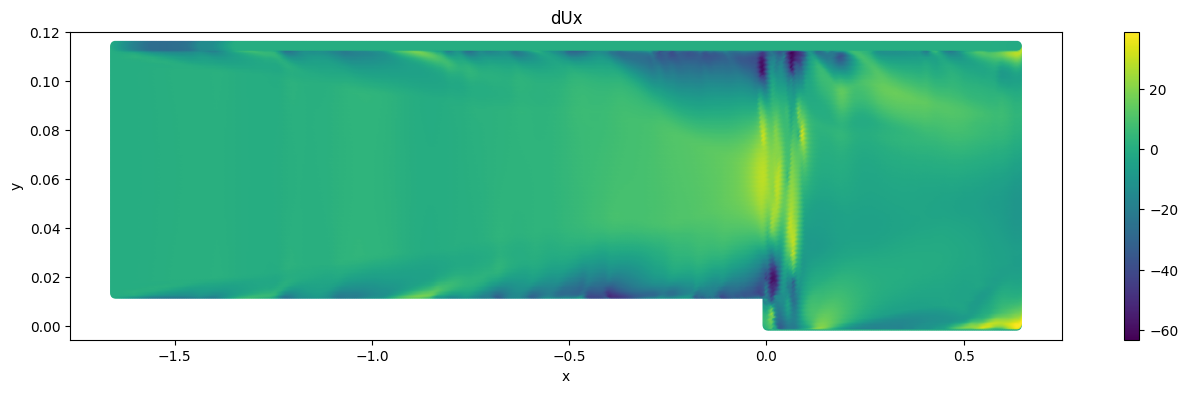

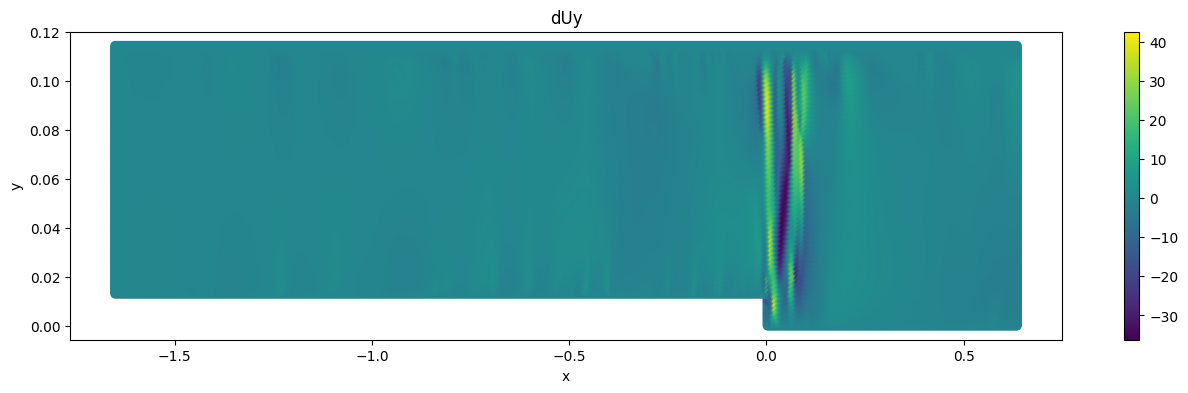

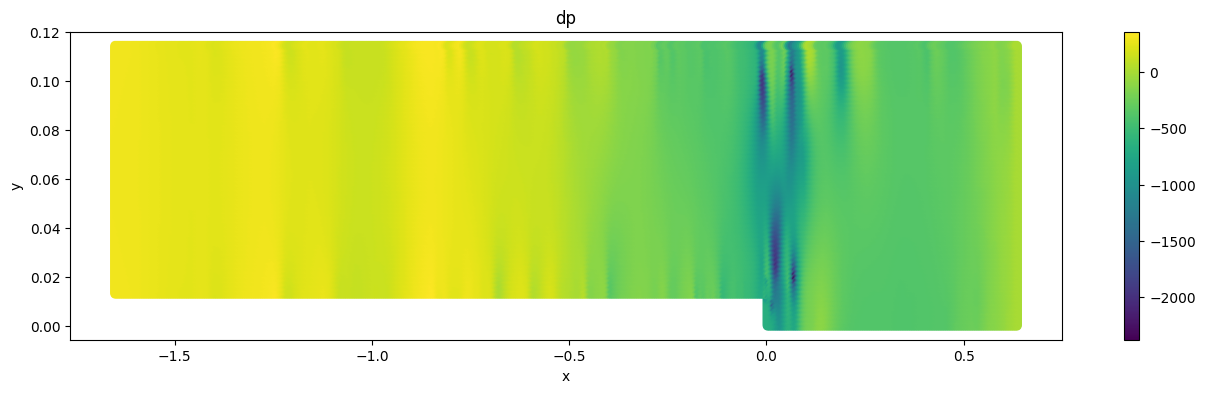

In [ ]:
plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["dUx"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("dUx")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["dUy"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("dUy")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["dp"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("dp")
plt.show()

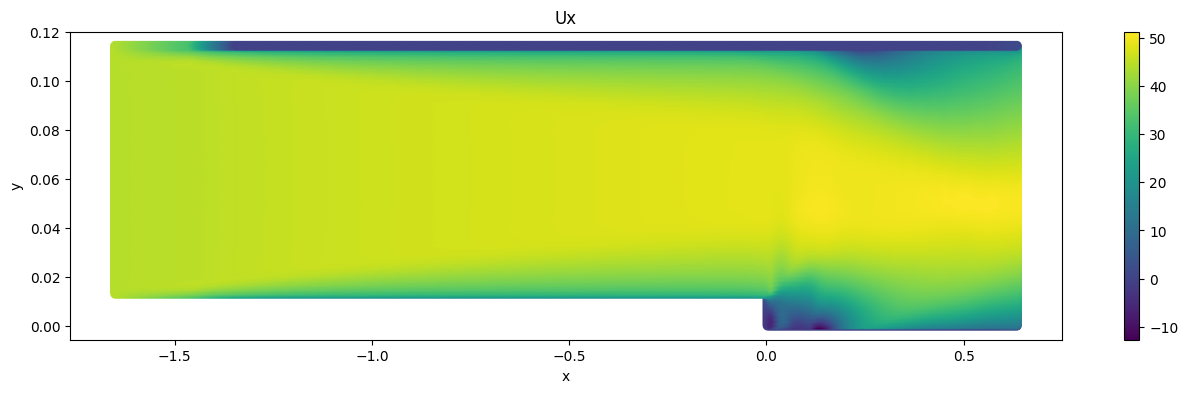

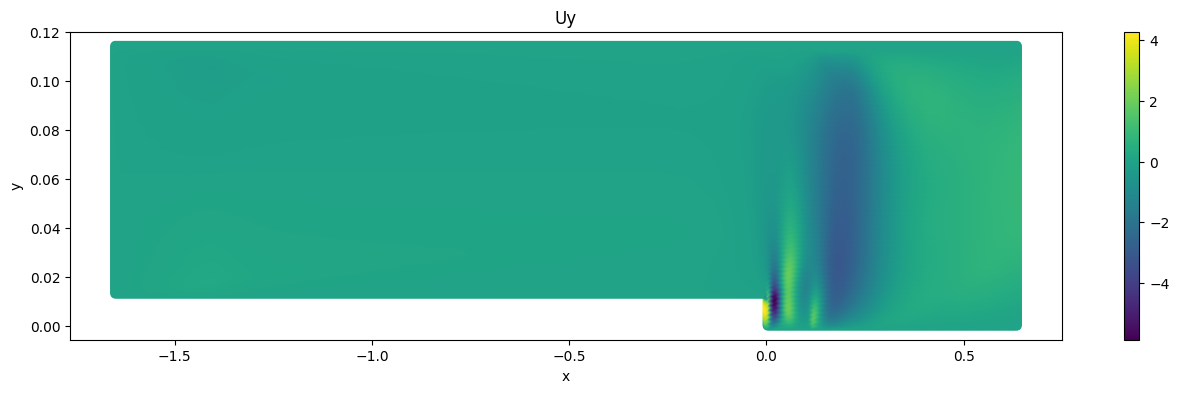

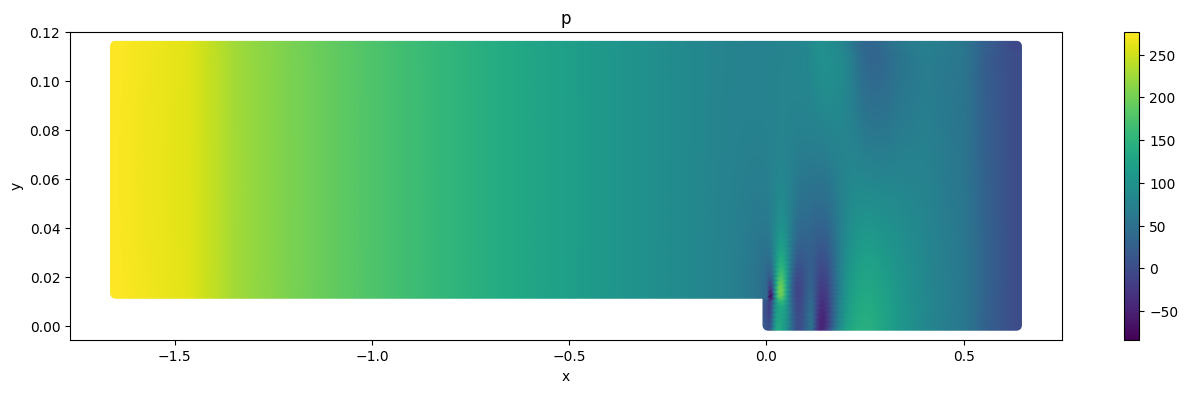

In [6]:
plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["Ux"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ux")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["Uy"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Uy")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["p"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("p")
plt.show()

## Treino de um MLP

In [52]:
# ----------------------------
# Definição do Modelo
# ----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, out_dim: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)


# ----------------------------
# Métricas
# ----------------------------
def mae_uv(u1, v1, u2, v2) -> float:
    """MAE vetorial médio: E[ sqrt((du)^2 + (dv)^2) ]"""
    return float(np.mean(np.sqrt((u1 - u2) ** 2 + (v1 - v2) ** 2)))

def mae_p(p1, p2):
    return float(np.mean(np.abs(p1 - p2)))

def rer(
    u_corr, v_corr,
    u_c, v_c,
    u_f, v_f
):
    num = np.sqrt(
        np.sum(
            (u_corr-u_f)**2 +
            (v_corr-v_f)**2
        )
    )

    den = np.sqrt(
        np.sum(
            (u_c-u_f)**2 +
            (v_c-v_f)**2
        )
    )

    if den < 1e-12:
        return np.nan

    return float(1.0 - num/den)

def rer_p(
    p_corr,
    p_c,
    p_f
):
    num = np.linalg.norm(p_corr-p_f)
    den = np.linalg.norm(p_c-p_f)

    if den < 1e-12:
        return np.nan

    return float(1.0 - num/den)

def rmse_uv(
    u1, v1,
    u2, v2
):
    return float(
        np.sqrt(
            np.mean(
                (u1-u2)**2 +
                (v1-v2)**2
            )
        )
    )

def rmse_p(
    p1,
    p2
):
    return float(
        np.sqrt(
            np.mean(
                (p1-p2)**2
            )
        )
    )

def l2_relative_uv(u_pred, v_pred, u_ref, v_ref):
    num = np.sqrt(np.sum((u_pred - u_ref)**2 + (v_pred - v_ref)**2))
    den = np.sqrt(np.sum(u_ref**2 + v_ref**2))
    return float(num / (den + 1e-12))

def l2_relative_p(p_pred, p_ref):
    num = np.linalg.norm(p_pred - p_ref)
    den = np.linalg.norm(p_ref)
    return float(num / (den + 1e-12))


# ----------------------------
# Treino
# ----------------------------
# original simple one:
df = pd.read_parquet(PATH_DATA / "dataset_bfs_2d_kepsilon.parquet")
feat_cols = ["x", "y", "Ux", "Uy", "p", "k", "log_nut", "Re"]

# this one with grads:
# df = pd.read_parquet("dataset_pitzDaily_with_grads.parquet")
# feat_cols = ["x", "y", "Ux", "Uy", "p", "dUx_dx", "dUx_dy", "dUy_dx", "dUy_dy", "Re"]

# this one with vorticity:
# df = pd.read_parquet(PATH_DATA / "dataset_pitzDaily_with_vorticity.parquet")
# feat_cols = [
# "x","y","Ux","Uy","p",
# "Um","wz",
# "dUx_dx","dUx_dy","dUy_dx","dUy_dy",
# "Re"
# ]

targ_cols = ["dUx", "dUy", "dp"]

X = df[feat_cols].values.astype(np.float32)
Y = df[targ_cols].values.astype(np.float32)

# guardamos indices pra puxar coarse/fine depois com consistência
idx_all = np.arange(len(df))

# 1) split: train vs temp (val+test)
X_tr, X_tmp, Y_tr, Y_tmp, idx_tr, idx_tmp = train_test_split(
    X, Y, idx_all, test_size=0.30, random_state=42, shuffle=True
)

# 2) split: val vs test (metade/metade do tmp => 15%/15%)
X_va, X_te, Y_va, Y_te, idx_va, idx_te = train_test_split(
    X_tmp, Y_tmp, idx_tmp, test_size=0.50, random_state=42, shuffle=True
)

# normalização (fit só no treino)
sx = StandardScaler().fit(X_tr)
sy = StandardScaler().fit(Y_tr)

X_tr_s = sx.transform(X_tr).astype(np.float32)
X_va_s = sx.transform(X_va).astype(np.float32)
X_te_s = sx.transform(X_te).astype(np.float32)

Y_tr_s = sy.transform(Y_tr).astype(np.float32)
Y_va_s = sy.transform(Y_va).astype(np.float32)
Y_te_s = sy.transform(Y_te).astype(np.float32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Xtr_t = torch.tensor(X_tr_s, device=device)
Ytr_t = torch.tensor(Y_tr_s, device=device)
Xva_t = torch.tensor(X_va_s, device=device)
Yva_t = torch.tensor(Y_va_s, device=device)

model = MLP(in_dim=X.shape[1], hidden=64, out_dim=3).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
loss_fn = nn.MSELoss()

# treino + early stopping na VAL
best_val = float("inf")
patience = 100
bad = 0
max_epochs = 3000

for epoch in range(1, max_epochs + 1):
    model.train()
    opt.zero_grad()
    pred = model(Xtr_t)
    loss = loss_fn(pred, Ytr_t)
    loss.backward()
    opt.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(Xva_t), Yva_t).item()

    if val_loss < best_val:
        best_val = val_loss
        bad = 0
        torch.save(model.state_dict(), PATH_MODEL / "mlp_k_eps_dU.pt")
    else:
        bad += 1

    if epoch % 300 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train={loss.item():.6e} | val={val_loss:.6e}")

    if bad >= patience:
        print("Early stopping (val não melhorou).")
        break

# salvar scalers
joblib.dump(sx, PATH_OUT / "scaler_X.pkl")
joblib.dump(sy, PATH_OUT / "scaler_Y.pkl")
print("Salvo: mlp_dU.pt, scaler_X.pkl, scaler_Y.pkl")

Epoch 001 | train=1.000078e+00 | val=9.795406e-01
Epoch 300 | train=3.724247e-01 | val=3.784459e-01
Epoch 600 | train=2.364883e-01 | val=2.470119e-01
Epoch 900 | train=1.905142e-01 | val=1.997405e-01
Epoch 1200 | train=1.681574e-01 | val=1.773869e-01
Epoch 1500 | train=1.519472e-01 | val=1.620504e-01
Epoch 1800 | train=1.382300e-01 | val=1.488139e-01
Epoch 2100 | train=1.298673e-01 | val=1.412520e-01
Epoch 2400 | train=1.174694e-01 | val=1.283249e-01
Epoch 2700 | train=1.100822e-01 | val=1.211681e-01
Epoch 3000 | train=1.033876e-01 | val=1.154120e-01
Salvo: mlp_dU.pt, scaler_X.pkl, scaler_Y.pkl


In [53]:
# ----------------------------
# Avaliação no TESTE
# ----------------------------
model.load_state_dict(torch.load(PATH_MODEL / "mlp_k_eps_dU.pt", map_location=device))
model.eval()

Xte_t = torch.tensor(X_te_s, device=device)
with torch.no_grad():
    d_pred_s = model(Xte_t).cpu().numpy()

d_pred = sy.inverse_transform(d_pred_s).astype(np.float64)

# campos coarse/fine do TESTE (usando idx_te)
u_c = df.loc[idx_te, "Ux"].values.astype(np.float64)
v_c = df.loc[idx_te, "Uy"].values.astype(np.float64)
p_c = df.loc[idx_te, "p"].values.astype(np.float64)
u_f = (df.loc[idx_te, "Ux"].values + df.loc[idx_te, "dUx"].values).astype(np.float64)
v_f = (df.loc[idx_te, "Uy"].values + df.loc[idx_te, "dUy"].values).astype(np.float64)
p_f = (df.loc[idx_te, "p"].values + df.loc[idx_te, "dp"].values).astype(np.float64)

u_corr = u_c + d_pred[:, 0]
v_corr = v_c + d_pred[:, 1]
p_corr = p_c + d_pred[:, 2]

mae_base = mae_uv(u_c, v_c, u_f, v_f)
mae_corr = mae_uv(u_corr, v_corr, u_f, v_f)
mae_p_base = mae_p(p_c, p_f)
mae_p_corr = mae_p(p_corr, p_f)
rer_val = rer(u_corr, v_corr, u_c, v_c, u_f, v_f)
rer_p_val = rer_p(p_corr, p_c, p_f)
rmse_uv_base = rmse_uv(u_c, v_c, u_f, v_f)
rmse_uv_corr = rmse_uv(u_corr, v_corr, u_f, v_f)
rmse_p_base = rmse_p(p_c, p_f)
rmse_p_corr = rmse_p(p_corr, p_f)
improve_mae_uv = 100.0 * (1.0 - mae_corr / mae_base) if mae_base > 0 else 0.0
improve_mae_p = 100.0 * (1.0 - mae_p_corr / mae_p_base) if mae_p_base > 0 else 0.0
l2_coarse_uv = l2_relative_uv(u_c, v_c, u_f, v_f)
l2_corr_uv   = l2_relative_uv(u_corr, v_corr, u_f, v_f)

l2_coarse_p = l2_relative_p(p_c, p_f)
l2_corr_p   = l2_relative_p(p_corr, p_f)

print("\n--- Métricas (TESTE) ---")
print(f"MAE (u,v) vetorial (coarse -> fine): {mae_base:.6f}")
print(f"MAE (p) escalar (coarse -> fine): {mae_p_base:.6f}")
print(f"RMSE (u,v) vetorial (coarse -> fine): {rmse_uv_base:.6f}")
print(f"RMSE (p) escalar (coarse -> fine): {rmse_p_base:.6f}")
print(f"MAE (u,v) vetorial (corrigido -> fine): {mae_corr:.6f}")
print(f"MAE (p) escalar (corrigido -> fine): {mae_p_corr:.6f}")
print(f"RMSE (u,v) vetorial (corrigido -> fine): {rmse_uv_corr:.6f}")
print(f"RMSE (p) escalar (corrigido -> fine): {rmse_p_corr:.6f}")
print(f"RER (u,v): {rer_val:.4f}")
print(f"RER (p): {rer_p_val:.4f}")
print(f"Melhora (u,v) (MAE): {improve_mae_uv:.2f}%")
print(f"Melhora (p) (MAE): {improve_mae_p:.2f}%")
print(f"L2 Relative (u,v): {l2_corr_uv:.6e}")
print(f"L2 Relative (p): {l2_corr_p:.6e}")

metrics = {
    "split": {"train": 0.70, "val": 0.15, "test": 0.15},
    "n_total": int(len(df)),
    "n_train": int(len(idx_tr)),
    "n_val": int(len(idx_va)),
    "n_test": int(len(idx_te)),
    "mae_base_test": mae_base,
    "mae_corr_test": mae_corr,
    "mae_p_base_test": mae_p_base,
    "mae_p_corr_test": mae_p_corr,
    "rmse_uv_base_test": rmse_uv_base,
    "rmse_uv_corr_test": rmse_uv_corr,
    "rmse_p_base_test": rmse_p_base,
    "rmse_p_corr_test": rmse_p_corr,
    "rer_uv_test": rer_val,
    "rer_p_test": rer_p_val,
    "improve_uv_mae_pct_test": improve_mae_uv,
    "improve_p_mae_pct_test": improve_mae_p,
    "best_val_loss_scaled": best_val,
    "device": str(device),
    "l2_relative_uv_test": l2_corr_uv,
    "l2_relative_p_test": l2_corr_p,
}

with open(PATH_OUT / "metrics_test.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Salvo: metrics_test.json")

# salvar previsões do TESTE (pra plotar só o teste)
out = df.loc[idx_te, ["x", "y", "Ux", "Uy", "p", "dUx", "dUy", "dp"]].copy()
out["dUx_pred"] = d_pred[:, 0]
out["dUy_pred"] = d_pred[:, 1]
out["dp_pred"] = d_pred[:, 2]
out["Ux_f"] = out["Ux"] + out["dUx"]
out["Uy_f"] = out["Uy"] + out["dUy"]
out["Ux_corr"] = out["Ux"] + out["dUx_pred"]
out["Uy_corr"] = out["Uy"] + out["dUy_pred"]
out["p_corr"] = out["p"] + out["dp_pred"]
out.to_parquet(PATH_OUT / "predictions_test.parquet", index=False)
print("Salvo: predictions_test.parquet (somente TESTE)")


--- Métricas (TESTE) ---
MAE (u,v) vetorial (coarse -> fine): 6.038899
MAE (p) escalar (coarse -> fine): 283.215563
RMSE (u,v) vetorial (coarse -> fine): 9.707374
RMSE (p) escalar (coarse -> fine): 344.080961
MAE (u,v) vetorial (corrigido -> fine): 1.513389
MAE (p) escalar (corrigido -> fine): 38.438022
RMSE (u,v) vetorial (corrigido -> fine): 2.872662
RMSE (p) escalar (corrigido -> fine): 71.187573
RER (u,v): 0.7041
RER (p): 0.7931
Melhora (u,v) (MAE): 74.94%
Melhora (p) (MAE): 86.43%
L2 Relative (u,v): 6.389828e-02
L2 Relative (p): 1.791771e-01
Salvo: metrics_test.json
Salvo: predictions_test.parquet (somente TESTE)


In [9]:
# ----------------------------
# Predição no DOMÍNIO TODO
# ----------------------------
X_all = df[feat_cols].values.astype(np.float32)   # use a mesma lista FEATURES do treino
X_all_s = sx.transform(X_all)

X_all_t = torch.tensor(X_all_s, device=device)

with torch.no_grad():
    d_all_pred_s = model(X_all_t).cpu().numpy()

d_all_pred = sy.inverse_transform(d_all_pred_s).astype(np.float64)

pred_all = df[["x", "y", "Ux", "Uy", "p", "dUx", "dUy", "dp"]].copy()

pred_all["Ux_f"] = pred_all["Ux"] + pred_all["dUx"]
pred_all["Uy_f"] = pred_all["Uy"] + pred_all["dUy"]
pred_all["p_f"]  = pred_all["p"]  + pred_all["dp"]

pred_all["dUx_pred"] = d_all_pred[:, 0]
pred_all["dUy_pred"] = d_all_pred[:, 1]
pred_all["dp_pred"]  = d_all_pred[:, 2]

pred_all["Ux_corr"] = pred_all["Ux"] + pred_all["dUx_pred"]
pred_all["Uy_corr"] = pred_all["Uy"] + pred_all["dUy_pred"]
pred_all["p_corr"]  = pred_all["p"]  + pred_all["dp_pred"]

pred_all.to_parquet(PATH_OUT / "predictions_all.parquet", index=False)
print("Salvo: predictions_all.parquet")

Salvo: predictions_all.parquet


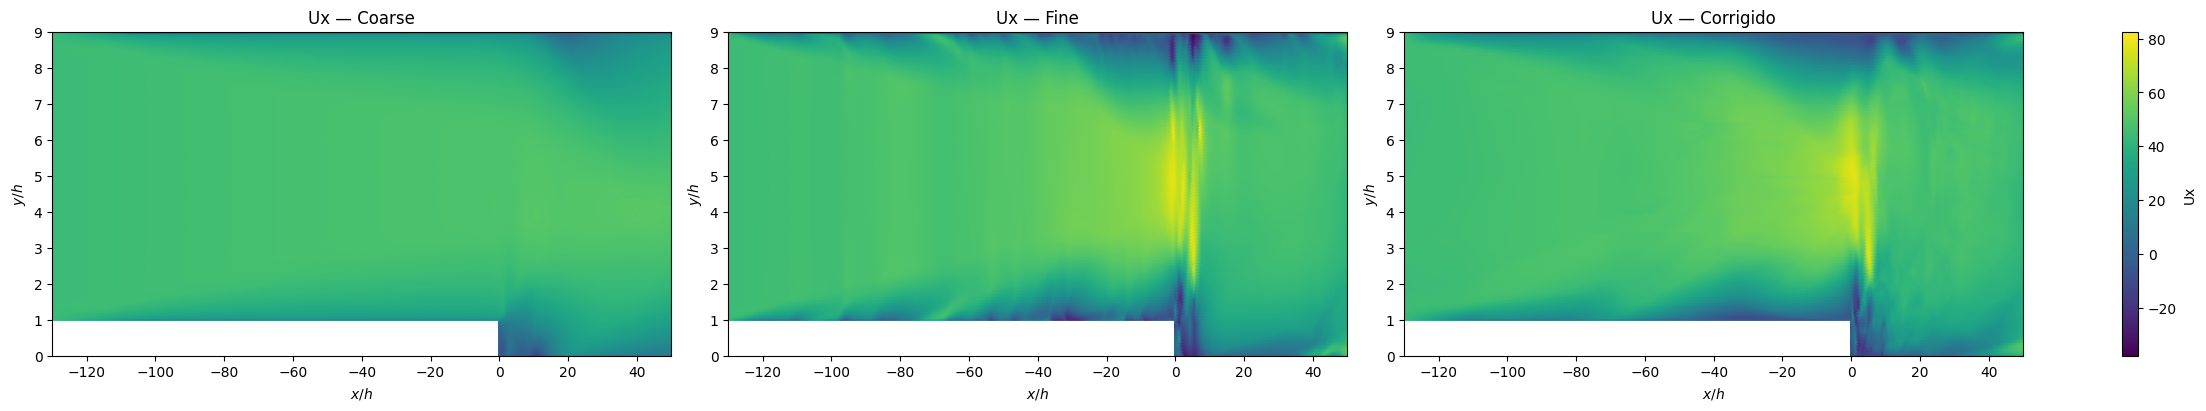

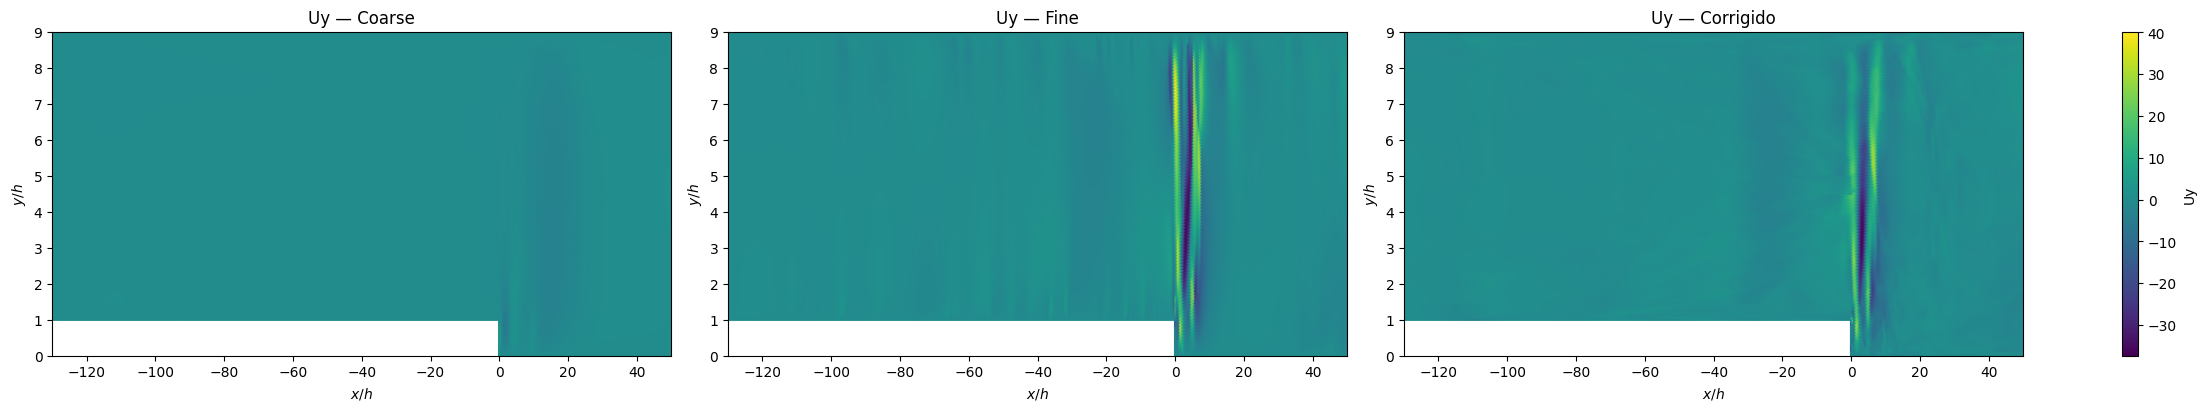

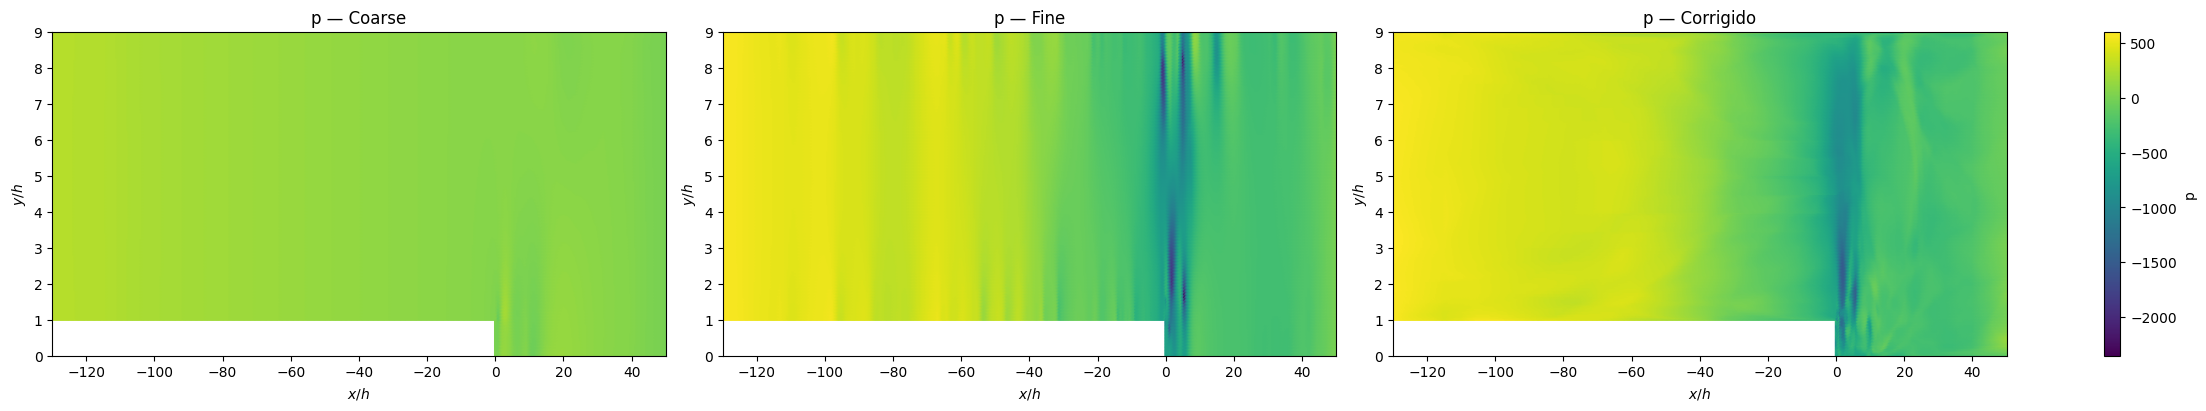

In [11]:
def plot_field_compare(
    df_plot,
    field_c,
    field_f,
    field_corr,
    title,
    h=0.0127,
    cmap="viridis"
):
    # Coordenadas adimensionais
    x = df_plot["x"].values / h
    y = df_plot["y"].values / h

    vals = np.concatenate([
        df_plot[field_c].values,
        df_plot[field_f].values,
        df_plot[field_corr].values
    ])

    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(22, 4),
        constrained_layout=True
    )

    titles = ["Coarse", "Fine", "Corrigido"]
    fields = [field_c, field_f, field_corr]

    for ax, f, t in zip(axes, fields, titles):

        sc = ax.scatter(
            x,
            y,
            c=df_plot[f].values,
            s=4,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(f"{title} — {t}")

        ax.set_xlabel(r"$x/h$")
        ax.set_ylabel(r"$y/h$")

        # Domínio do Driver & Seegmiller
        ax.set_xlim([-130, 50])
        ax.set_ylim([0, 9])

        # Não preservar a razão física extrema
        ax.set_aspect("auto")

    fig.colorbar(sc, ax=axes, label=title)

    plt.show()

plot_field_compare(pred_all, "Ux", "Ux_f", "Ux_corr", "Ux")
plot_field_compare(pred_all, "Uy", "Uy_f", "Uy_corr", "Uy")
plot_field_compare(pred_all, "p", "p_f", "p_corr", "p")

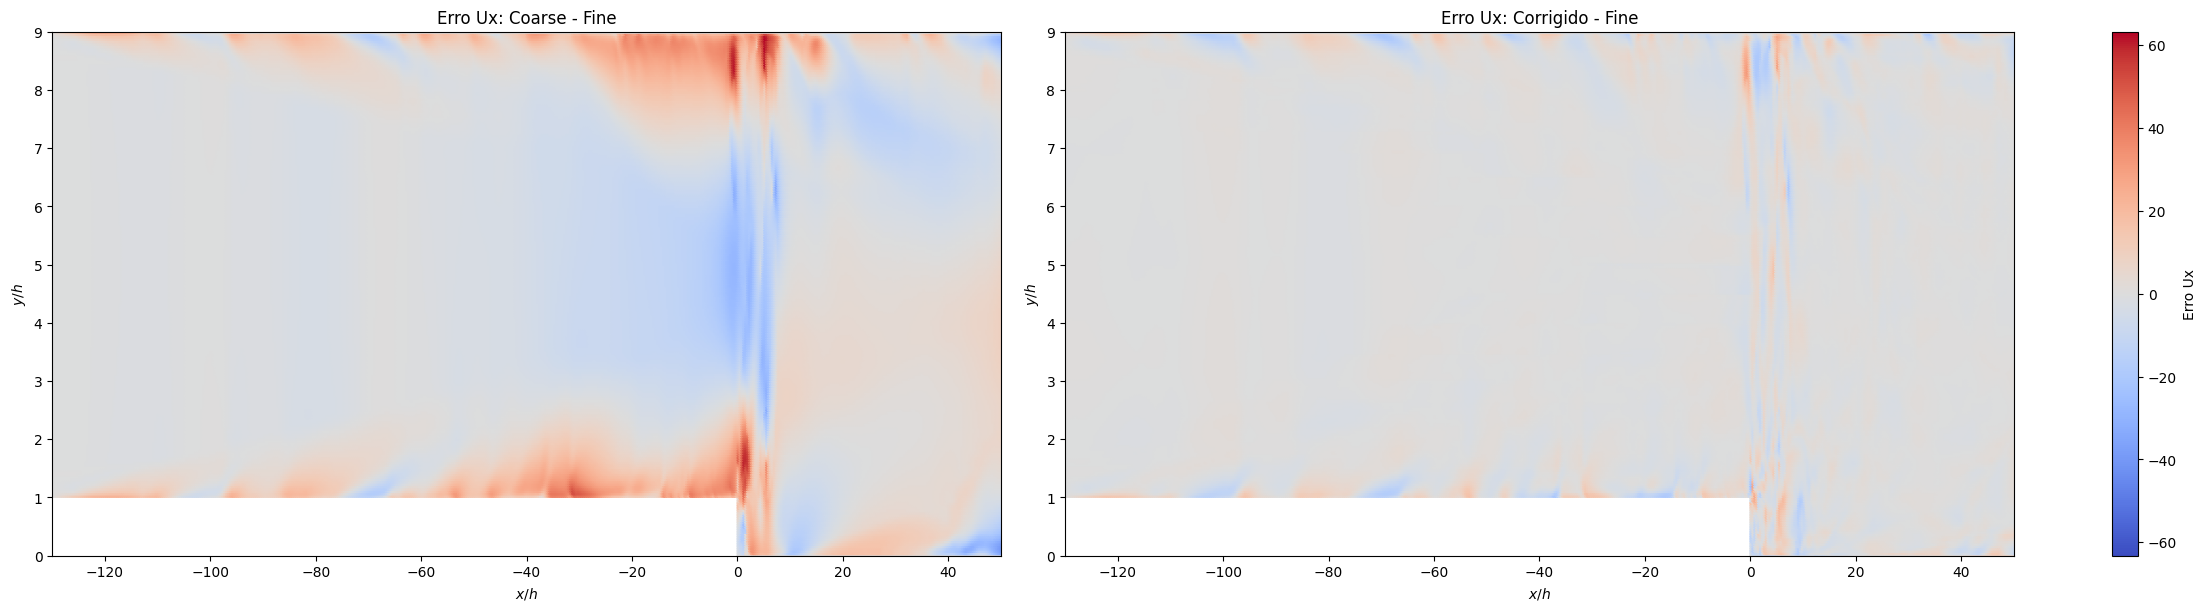

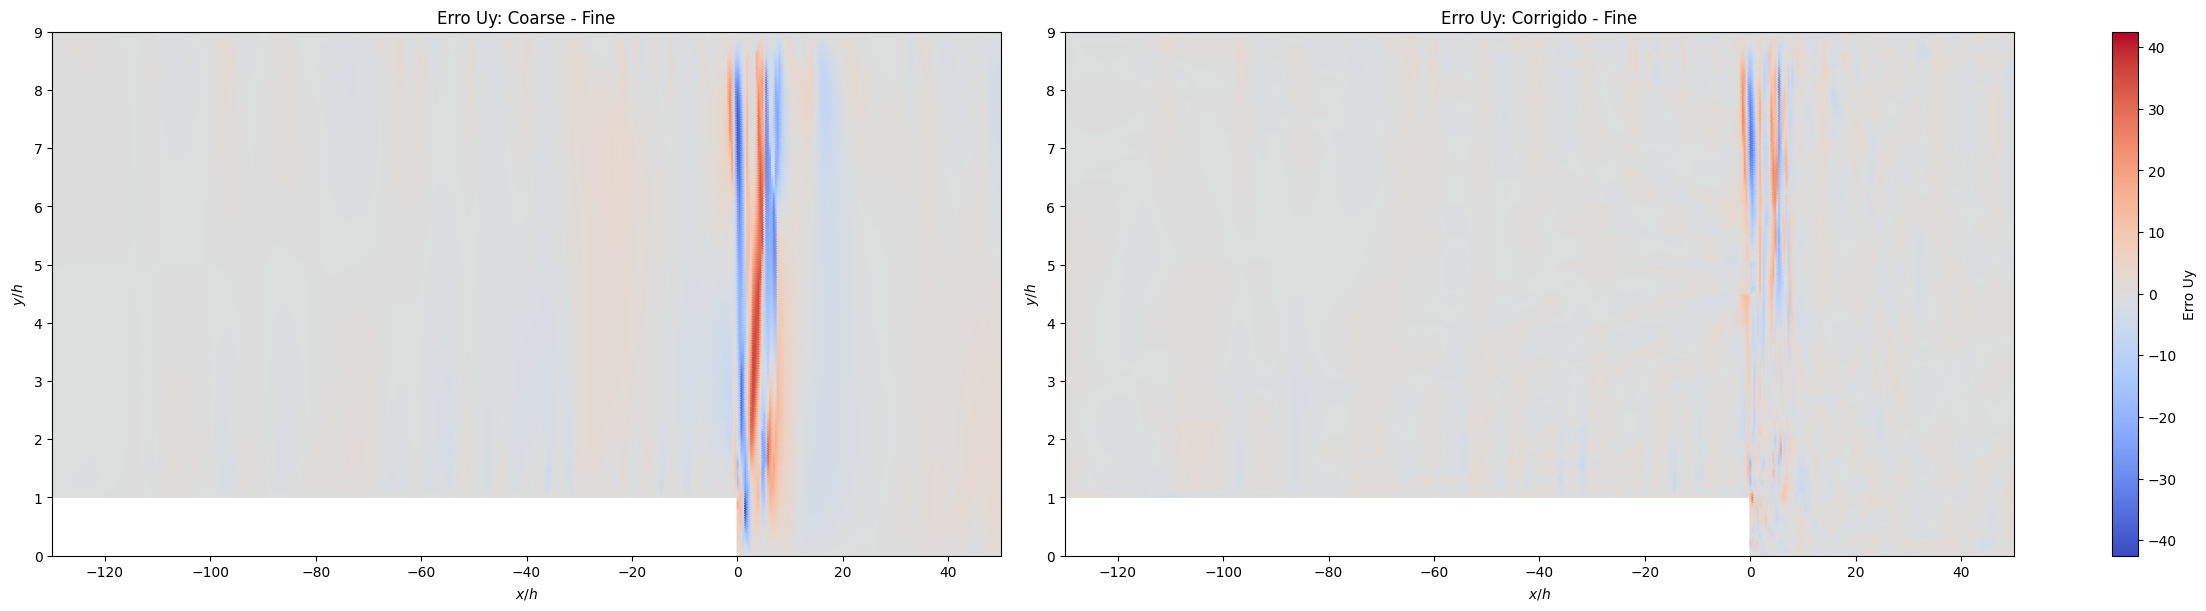

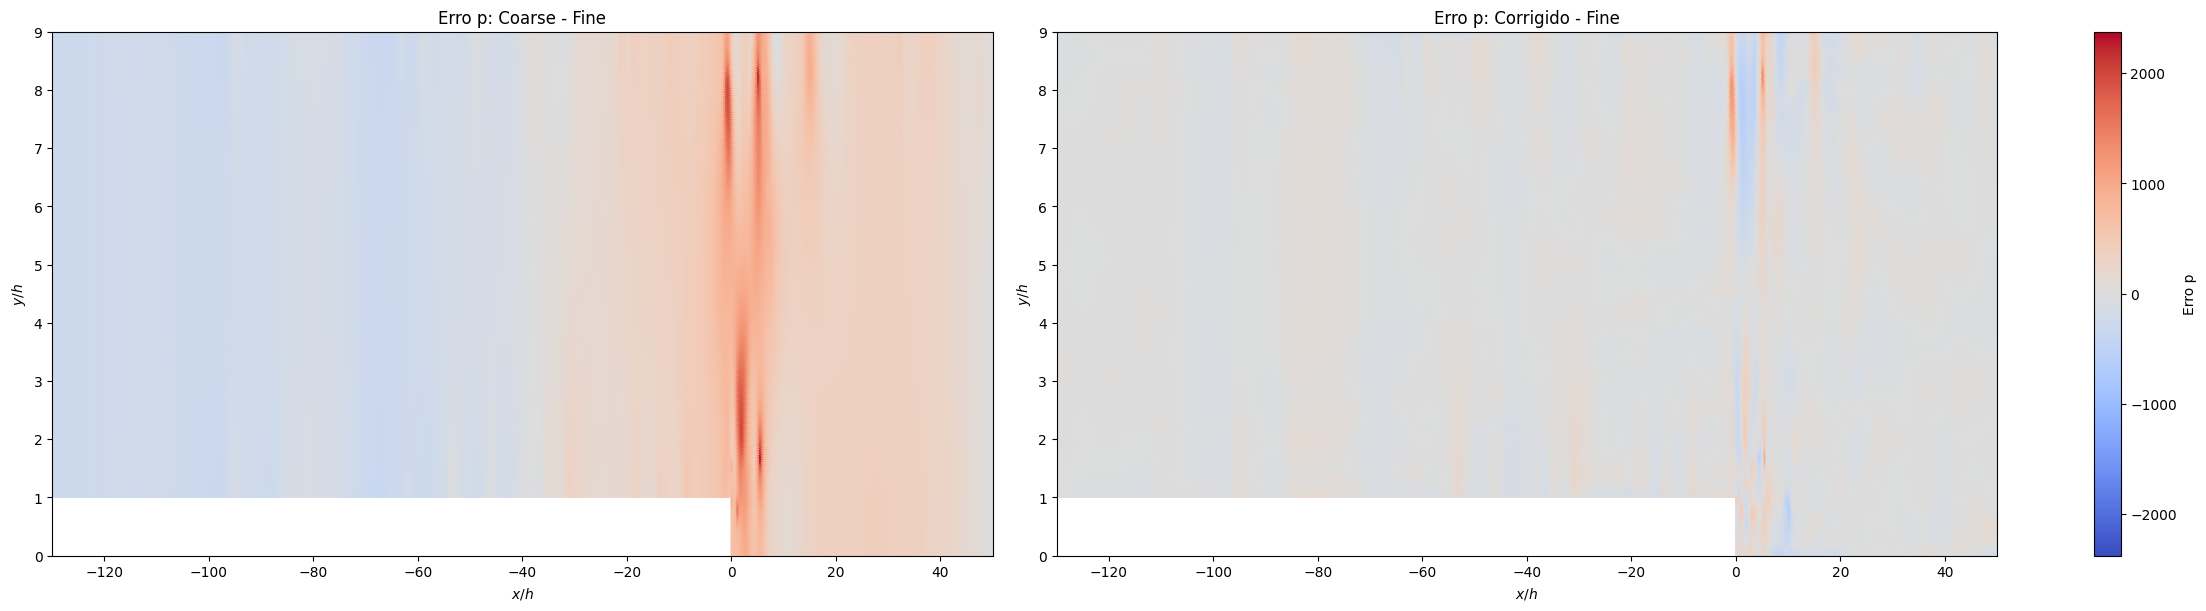

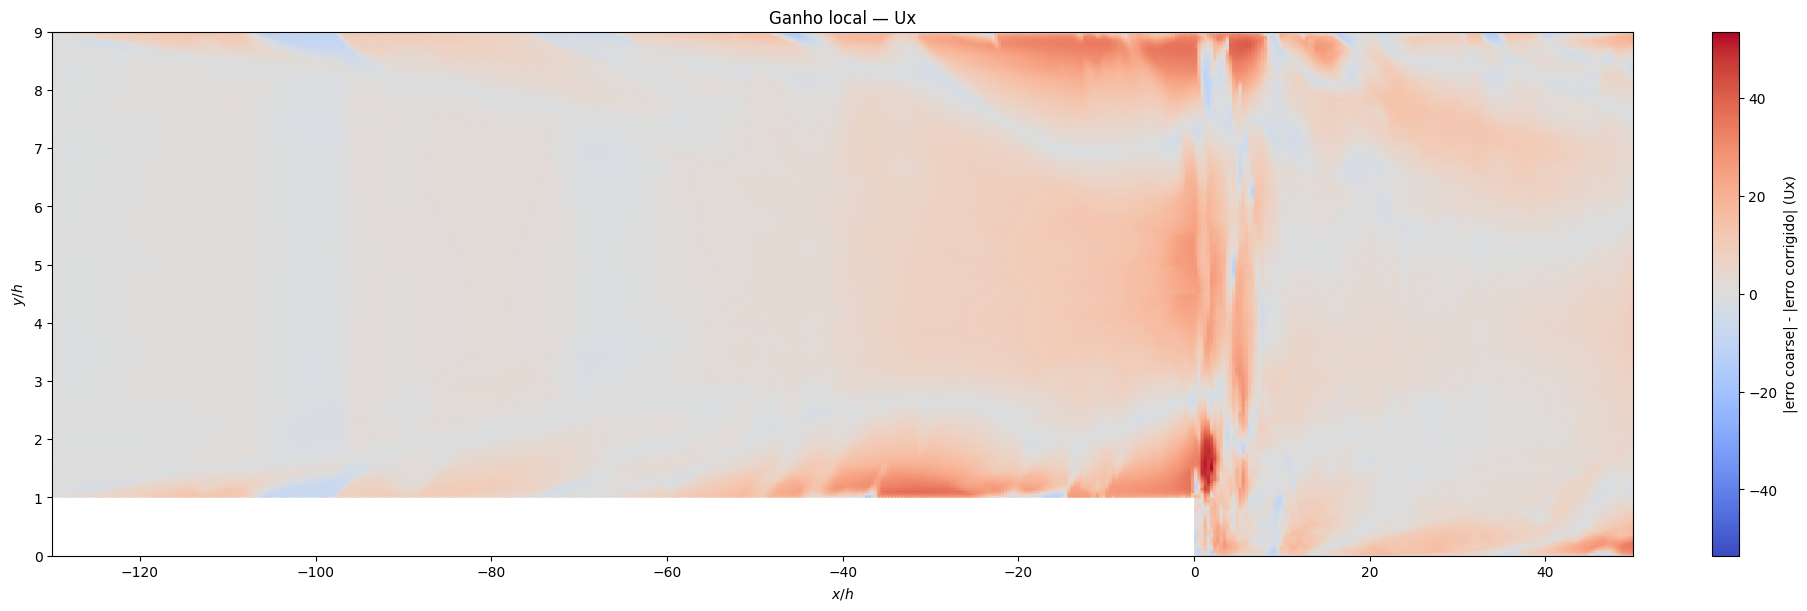

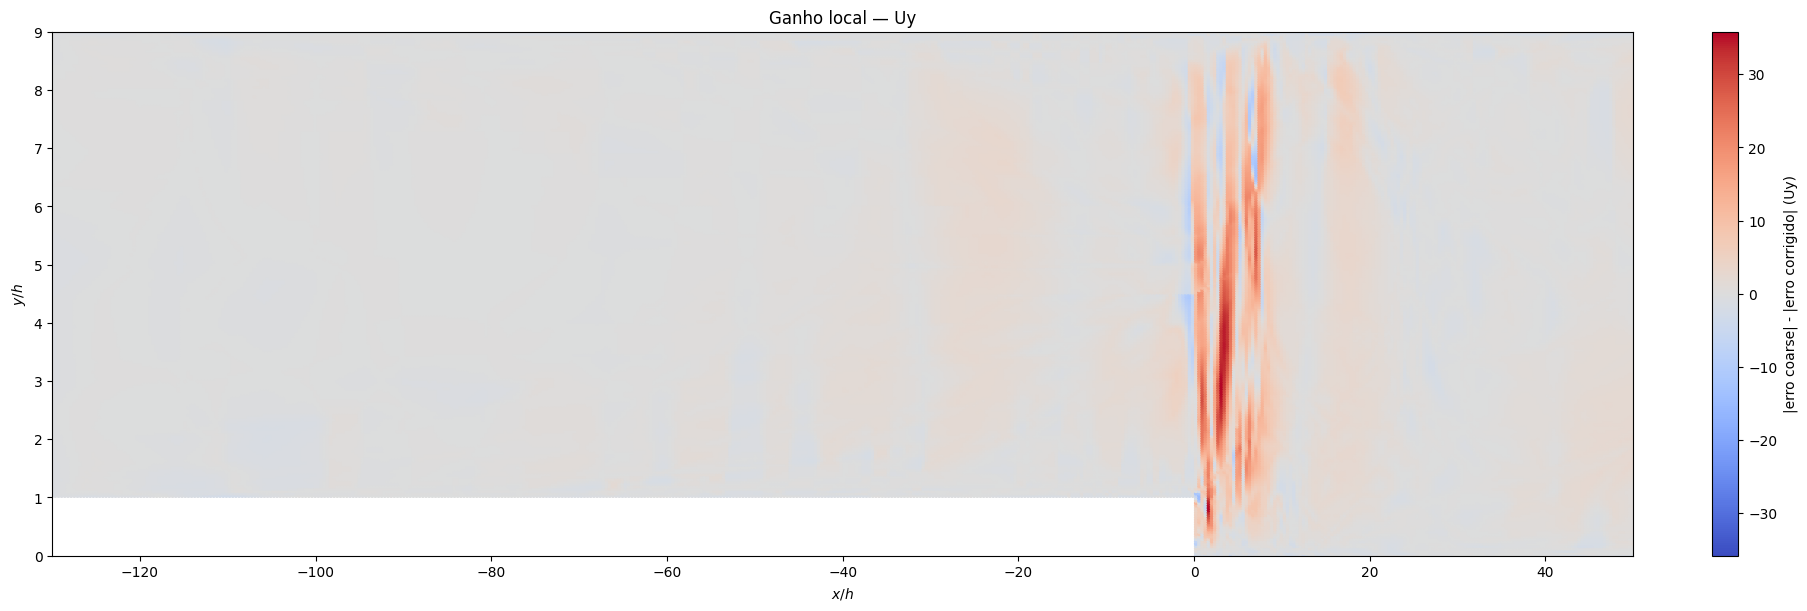

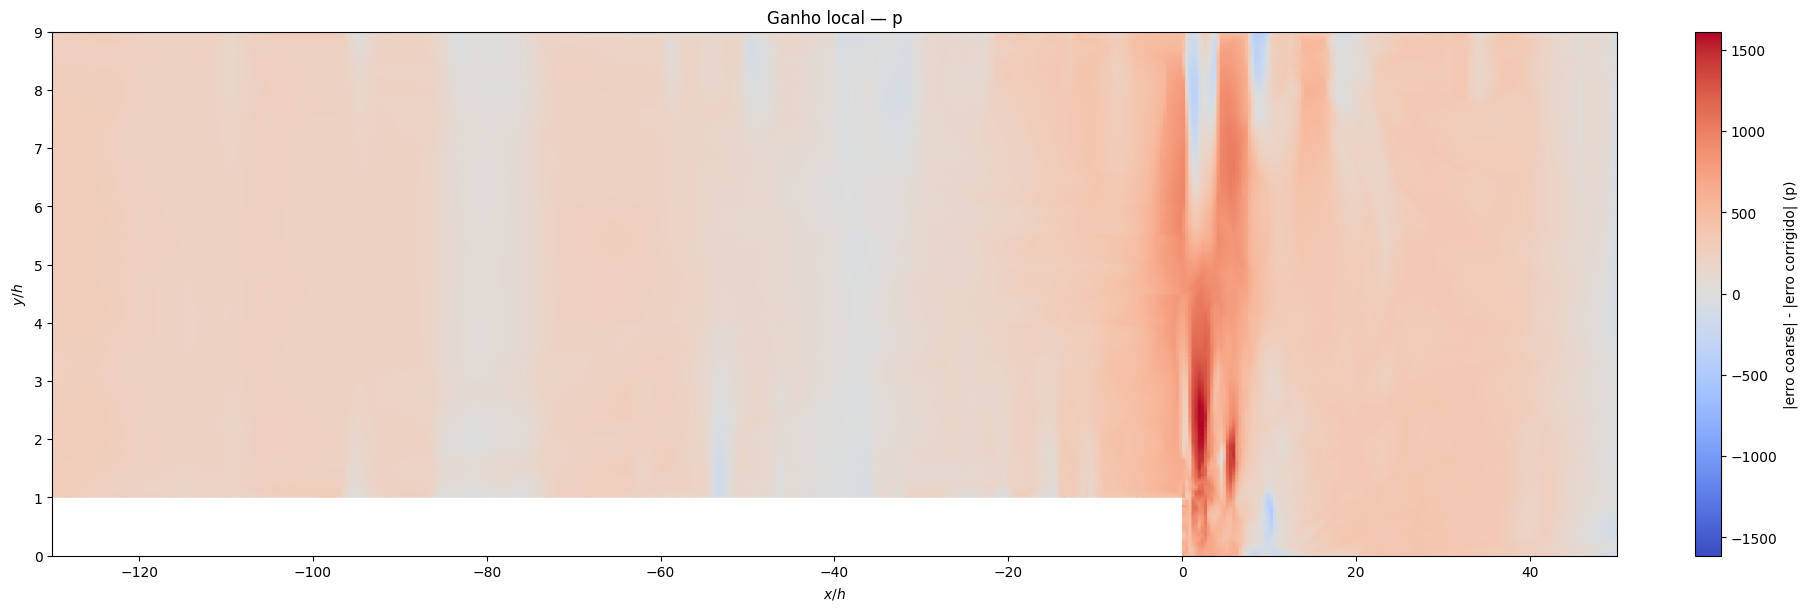

In [12]:
# -------------------------------------------------
# 1. Mapas de erro: Coarse - Fine vs Corrigido - Fine
# -------------------------------------------------

def plot_error_compare(
    df_plot,
    field_c,
    field_f,
    field_corr,
    label,
    h=0.0127,
    save_path=None
):
    x = df_plot["x"].values / h
    y = df_plot["y"].values / h

    err_base = df_plot[field_c].values - df_plot[field_f].values
    err_corr = df_plot[field_corr].values - df_plot[field_f].values

    vmax = max(
        np.nanmax(np.abs(err_base)),
        np.nanmax(np.abs(err_corr))
    )
    vmin = -vmax

    fig, axes = plt.subplots(
        1, 2,
        figsize=(22, 6),
        constrained_layout=True
    )

    plots = [
        (axes[0], err_base, f"Erro {label}: Coarse - Fine"),
        (axes[1], err_corr, f"Erro {label}: Corrigido - Fine"),
    ]

    for ax, err, title in plots:
        sc = ax.scatter(
            x, y,
            c=err,
            s=4,
            cmap="coolwarm",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(title)
        ax.set_xlabel(r"$x/h$")
        ax.set_ylabel(r"$y/h$")
        ax.set_xlim([-130, 50])
        ax.set_ylim([0, 9])
        ax.set_aspect("auto")

    fig.colorbar(sc, ax=axes, label=f"Erro {label}")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# -------------------------------------------------
# 2. Ganho local: |erro coarse| - |erro corrigido|
# -------------------------------------------------

def plot_local_gain(
    df_plot,
    field_c,
    field_f,
    field_corr,
    label,
    h=0.0127,
    save_path=None
):
    x = df_plot["x"].values / h
    y = df_plot["y"].values / h

    err_base = df_plot[field_c].values - df_plot[field_f].values
    err_corr = df_plot[field_corr].values - df_plot[field_f].values

    gain = np.abs(err_base) - np.abs(err_corr)

    vmax = np.nanmax(np.abs(gain))
    vmin = -vmax

    fig, ax = plt.subplots(figsize=(18, 6), constrained_layout=True)

    sc = ax.scatter(
        x, y,
        c=gain,
        s=4,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"Ganho local — {label}")
    ax.set_xlabel(r"$x/h$")
    ax.set_ylabel(r"$y/h$")
    ax.set_xlim([-130, 50])
    ax.set_ylim([0, 9])
    ax.set_aspect("auto")

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f"|erro coarse| - |erro corrigido| ({label})")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# -------------------------------------------------
# 3. Executar para Ux, Uy e p
# -------------------------------------------------

plot_error_compare(
    pred_all,
    field_c="Ux",
    field_f="Ux_f",
    field_corr="Ux_corr",
    label="Ux",
    save_path=PATH_OUT / "erro_Ux_coarse_vs_corrigido.png"
)

plot_error_compare(
    pred_all,
    field_c="Uy",
    field_f="Uy_f",
    field_corr="Uy_corr",
    label="Uy",
    save_path=PATH_OUT / "erro_Uy_coarse_vs_corrigido.png"
)

plot_error_compare(
    pred_all,
    field_c="p",
    field_f="p_f",
    field_corr="p_corr",
    label="p",
    save_path=PATH_OUT / "erro_p_coarse_vs_corrigido.png"
)

plot_local_gain(
    pred_all,
    field_c="Ux",
    field_f="Ux_f",
    field_corr="Ux_corr",
    label="Ux",
    save_path=PATH_OUT / "ganho_local_Ux.png"
)

plot_local_gain(
    pred_all,
    field_c="Uy",
    field_f="Uy_f",
    field_corr="Uy_corr",
    label="Uy",
    save_path=PATH_OUT / "ganho_local_Uy.png"
)

plot_local_gain(
    pred_all,
    field_c="p",
    field_f="p_f",
    field_corr="p_corr",
    label="p",
    save_path=PATH_OUT / "ganho_local_p.png"
)

A correção aprendida pela MLP reduz significativamente o erro coarse→fine, preservando a maior parte do domínio com erro residual baixo. As maiores discrepâncias remanescentes concentram-se na região de separação e reatacamento, onde os gradientes do escoamento são mais intensos.

In [13]:
def plot_error_histogram(
    df_plot,
    field_c,
    field_f,
    field_corr,
    label,
    bins=100,
    save_path=None
):
    err_coarse = np.abs(
        df_plot[field_c].values -
        df_plot[field_f].values
    )

    err_corr = np.abs(
        df_plot[field_corr].values -
        df_plot[field_f].values
    )

    fig, ax = plt.subplots(
        figsize=(8, 5),
        constrained_layout=True
    )

    ax.hist(
        err_coarse,
        bins=bins,
        alpha=0.6,
        density=True,
        label="Coarse",
        edgecolor="black"
    )

    ax.hist(
        err_corr,
        bins=bins,
        alpha=0.6,
        density=True,
        label="Corrigido",
        edgecolor="black"
    )

    ax.set_xlabel(f"|Erro| ({label})")
    ax.set_ylabel("Densidade")

    ax.set_title(
        f"Distribuição do erro absoluto - {label}"
    )

    ax.legend()
    ax.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


def plot_scatter_prediction(
    df_plot,
    field_f,
    field_corr,
    label,
    sample_frac=1.0,
    save_path=None
):
    df_tmp = df_plot

    if sample_frac < 1.0:
        df_tmp = df_plot.sample(
            frac=sample_frac,
            random_state=42
        )

    x = df_tmp[field_f].values
    y = df_tmp[field_corr].values

    lim_min = min(x.min(), y.min())
    lim_max = max(x.max(), y.max())

    fig, ax = plt.subplots(
        figsize=(6, 6),
        constrained_layout=True
    )

    ax.scatter(
        x,
        y,
        s=3,
        alpha=0.3
    )

    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        'r--',
        linewidth=2,
        label="y=x"
    )

    ax.set_xlabel(f"{label} Fine")
    ax.set_ylabel(f"{label} Corrigido")

    ax.set_title(
        f"{label}: Predito vs Referência"
    )

    ax.legend()
    ax.grid(True, alpha=0.3)

    ax.set_aspect("equal")

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

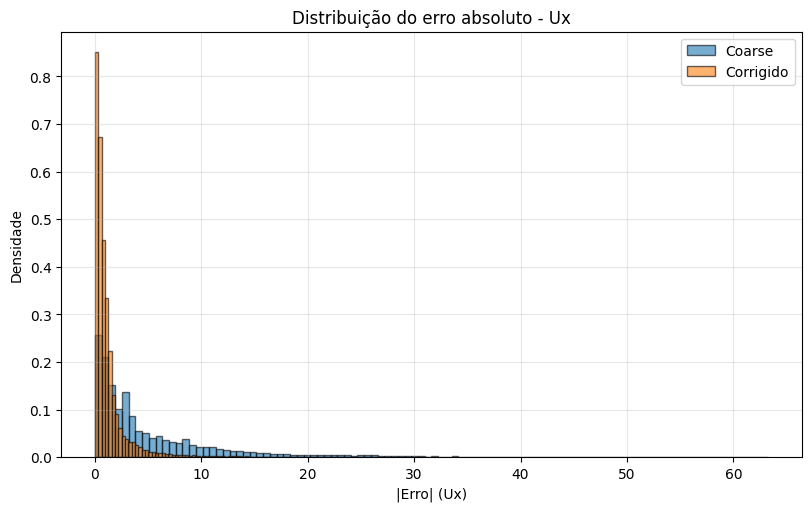

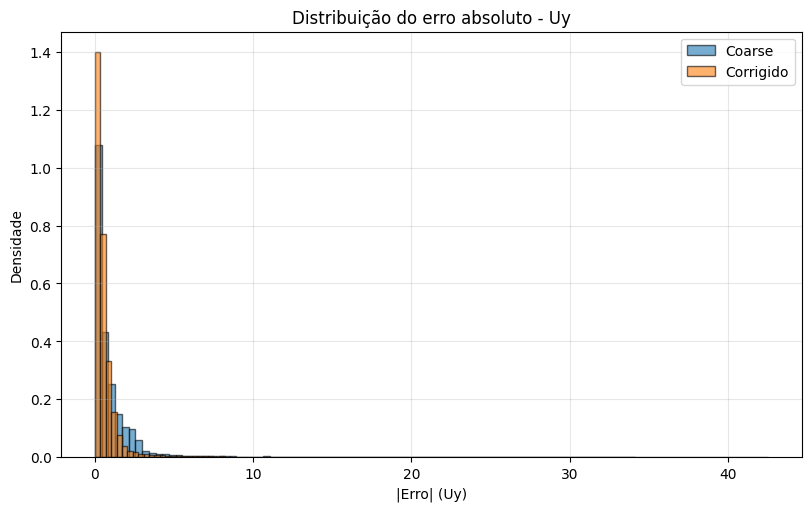

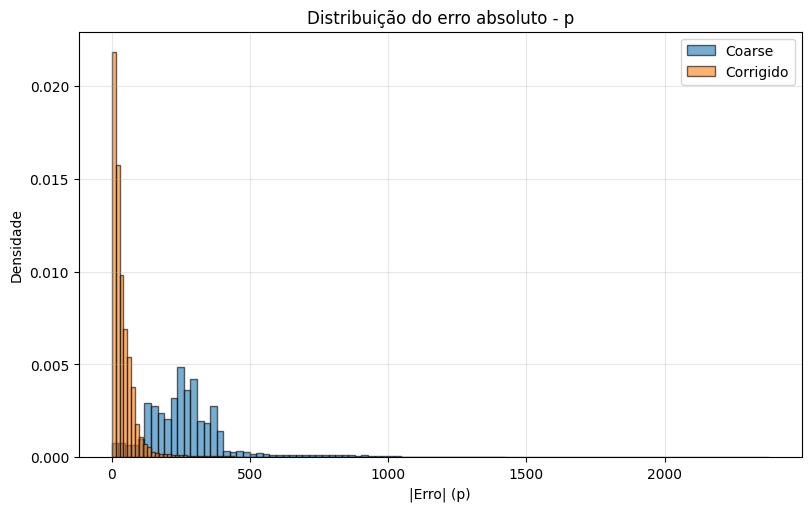

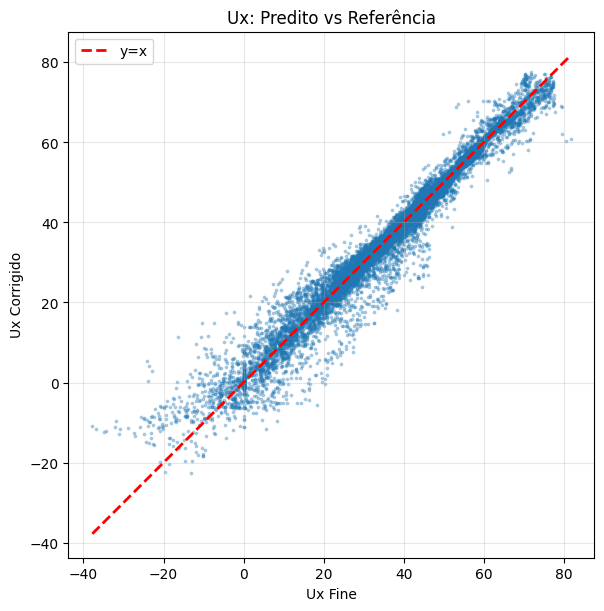

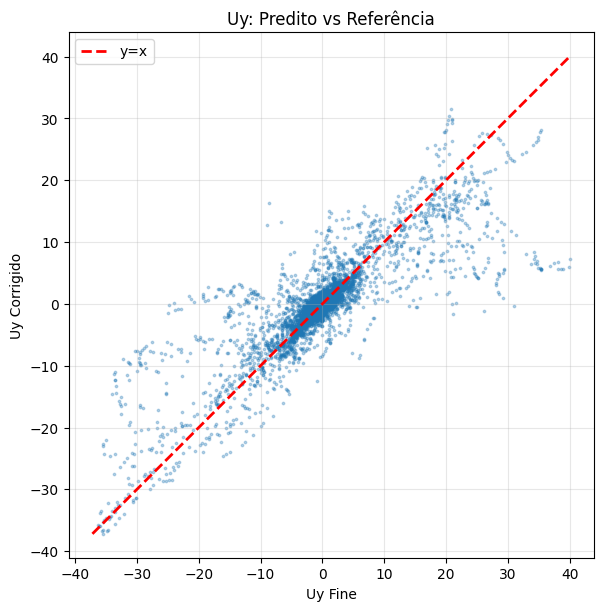

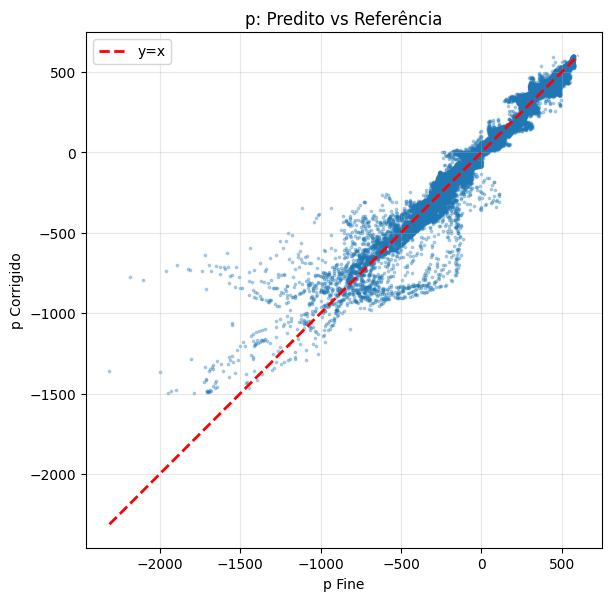

In [14]:
plot_error_histogram(
    pred_all,
    "Ux",
    "Ux_f",
    "Ux_corr",
    "Ux",
    save_path=PATH_OUT / "hist_error_Ux.png"
)

plot_error_histogram(
    pred_all,
    "Uy",
    "Uy_f",
    "Uy_corr",
    "Uy",
    save_path=PATH_OUT / "hist_error_Uy.png"
)

plot_error_histogram(
    pred_all,
    "p",
    "p_f",
    "p_corr",
    "p",
    save_path=PATH_OUT / "hist_error_p.png"
)

plot_scatter_prediction(
    pred_all,
    "Ux_f",
    "Ux_corr",
    "Ux",
    sample_frac=0.3,
    save_path=PATH_OUT / "scatter_Ux.png"
)

plot_scatter_prediction(
    pred_all,
    "Uy_f",
    "Uy_corr",
    "Uy",
    sample_frac=0.3,
    save_path=PATH_OUT / "scatter_Uy.png"
)

plot_scatter_prediction(
    pred_all,
    "p_f",
    "p_corr",
    "p",
    sample_frac=0.3,
    save_path=PATH_OUT / "scatter_p.png"
)

As distribuições de erro absoluto apresentaram forte concentração em torno de zero após a correção via MLP, acompanhada pela redução das caudas de alta magnitude. Isso indica que o modelo não apenas reduz erros pontuais, mas melhora sistematicamente a solução em praticamente todo o domínio computacional.

In [15]:
from sklearn.metrics import r2_score

print("R2 Ux :", r2_score(pred_all["Ux_f"], pred_all["Ux_corr"]))
print("R2 Uy :", r2_score(pred_all["Uy_f"], pred_all["Uy_corr"]))
print("R2 p  :", r2_score(pred_all["p_f"], pred_all["p_corr"]))

R2 Ux : 0.9678207130276193
R2 Uy : 0.7161777365543924
R2 p  : 0.9587433215497334


# Treino da PINN

## Estrutura e modelo PINN

In [54]:
# PINN corretor: aprende ΔU e Δp para corrigir coarse -> aproximar fine
# Requer no parquet: FEAT_COLS e TARGET_COLS (além de x,y pra plotar depois)
# Ajuste os nomes das colunas de target conforme seu dataset.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

# -----------------------------
# 1) Dataset
# -----------------------------
class CFDParquet(Dataset):
    def __init__(self, df, feat_cols, target_cols=None, x_scaler=None, y_scaler=None):
        self.X = df[feat_cols].to_numpy(dtype=np.float32)
        self.has_y = target_cols is not None
        self.Y = df[target_cols].to_numpy(dtype=np.float32) if self.has_y else None

        # scaler só para features (z-score)
        if x_scaler is None:
            mu = self.X.mean(axis=0, keepdims=True)
            sd = self.X.std(axis=0, keepdims=True) + 1e-8
            self.x_mu = mu
            self.x_sd = sd
        else:
            self.x_mu, self.x_sd = x_scaler

        if self.has_y:
            y_mu = self.Y.mean(axis=0, keepdims=True)
            y_sd = self.Y.std(axis=0, keepdims=True) + 1e-8
            self.y_mu = y_mu
            self.y_sd = y_sd
            
        else:
            self.y_mu, self.y_sd = y_scaler
        
        # normaliza X e Y
        self.Xn = (self.X - self.x_mu) / self.x_sd
        self.Yn = (self.Y - self.y_mu) / self.y_sd

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        x = torch.tensor(self.Xn[idx], dtype=DTYPE)
        if self.has_y:
            y = torch.tensor(self.Yn[idx], dtype=DTYPE)
            return x, y
        return x


# -----------------------------
# 2) Modelo
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, width=128, depth=5, act=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, width), act()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), act()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)

        # init leve (ajuda tanh)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# -----------------------------
# 3) Autodiff util
# -----------------------------
def grad(outputs, inputs):
    # outputs: (N,1) or (N,)
    # inputs: (N,1)
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]

def laplacian(f, x, y):
    fx = grad(f, x)
    fy = grad(f, y)
    fxx = grad(fx, x)
    fyy = grad(fy, y)
    return fxx + fyy

## Etapa 1 — PINN só com continuidade

In [57]:
# -----------------------------
# Definindo os Resíduos físicos (2D incompressível, estacionário) - Só continuidade
# -----------------------------
def pde_residuals_continuity(x, y, u_coarse, v_coarse, model_out):
    """
    x, y: (N,1) leaf tensors com requires_grad=True (os mesmos do forward)
    model_out:
      se predict_dp=True: (N,3) = [dU, dV, dP]
      senão: (N,2) = [dU, dV]
    """

    dU, dV = model_out[:, [0]], model_out[:, [1]]

    u_hat = u_coarse + dU
    v_hat = v_coarse + dV

    # derivadas
    u_x = grad(u_hat, x)
    v_y = grad(v_hat, y)

    r_cont = u_x + v_y

    return r_cont


FEAT_COLS = ["x", "y", "Ux", "Uy", "p", "k"]

# ajuste aqui se seus targets têm outros nomes
TARGET_COLS = ["dUx", "dUy", "dp"]  # (ΔUx_true, ΔUy_true)
HAS_TARGETS = True           # se quiser rodar sem supervisão, coloque False

# -----------------------------
# Função de Treino
# -----------------------------
def train_pinn(
    parquet_path,
    batch_data=4096,
    batch_phys=4096,
    epochs_pre=50,
    epochs_phys=100,
    lr=1e-3,
    w_data=1.0,
    w_cont=1.0,
    predict_dp=True,
    seed=42
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    df = pd.read_parquet(parquet_path)

    # Split simples (pode trocar por split espacial/estratificado por região de wz)
    n = len(df)
    idx = np.random.permutation(n)
    ntr = int(0.8 * n)
    tr_idx, te_idx = idx[:ntr], idx[ntr:]

    df_tr = df.iloc[tr_idx].reset_index(drop=True)
    df_te = df.iloc[te_idx].reset_index(drop=True)

    # Dataset supervisionado (dados)
    train_ds = CFDParquet(df_tr, FEAT_COLS, TARGET_COLS if HAS_TARGETS else None)
    test_ds  = CFDParquet(df_te, FEAT_COLS, TARGET_COLS if HAS_TARGETS else None,
                      x_scaler=(train_ds.x_mu, train_ds.x_sd), 
                      y_scaler=(train_ds.y_mu, train_ds.y_sd))


    dl_data = DataLoader(train_ds, batch_size=batch_data, shuffle=True, drop_last=True)

    in_dim = len(FEAT_COLS)
    out_dim = 3 if predict_dp else 2
    net = MLP(in_dim=in_dim, out_dim=out_dim, width=128, depth=5, act=nn.Tanh).to(DEVICE)

    opt = torch.optim.Adam(net.parameters(), lr=lr)

    # helper: pegar colunas específicas do batch (já normalizado) e voltar pra escala original
    # aqui a gente precisa de x,y,Ux,Uy,p,Re em escala original pra PDE.
    feat_index = {c: i for i, c in enumerate(FEAT_COLS)}

    x_mu = torch.as_tensor(train_ds.x_mu, dtype=DTYPE, device=DEVICE)
    x_sd = torch.as_tensor(train_ds.x_sd, dtype=DTYPE, device=DEVICE)
    y_mu = torch.as_tensor(train_ds.y_mu, dtype=DTYPE, device=DEVICE)
    y_sd = torch.as_tensor(train_ds.y_sd, dtype=DTYPE, device=DEVICE)

    def unnormalize_X(Xn):
        return Xn * x_sd + x_mu
    
    def denorm_y(yn, y_mu, y_sd):
        return yn * y_sd + y_mu

    # ---- STAGE 1: pré-treino supervisionado (dados)
    if HAS_TARGETS and epochs_pre > 0:
        net.train()
        for ep in range(1, epochs_pre + 1):
            total = 0.0
            for Xn, Yn in dl_data:
                Xn = Xn.to(DEVICE)
                Yn = Yn.to(DEVICE)

                pred = net(Xn)
                loss = torch.mean((pred - Yn) ** 2) 

                opt.zero_grad()
                loss.backward()
                opt.step()

                total += loss.item()

            if ep % 10 == 0 or ep == 1:
                print(f"[PRE] ep={ep:03d} loss_data={total/len(dl_data):.6e}")

    # ---- STAGE 2: dados + física (REFATORADO / SEM detach no caminho de x,y)
    net.train()
    for ep in range(1, epochs_phys + 1):
        total_loss = 0.0
        total_data = 0.0
        total_cont = 0.0

        for batch in dl_data:
            if HAS_TARGETS:
                Xn, Yn = batch
                Xn = Xn.to(DEVICE)
                Yn = Yn.to(DEVICE)
            else:
                Xn = batch
                Xn = Xn.to(DEVICE)
                Yn = None

            # =========================
            # (1) Loss de dados (ΔU)
            # =========================
            pred_data = net(Xn)  # forward normal
            loss_data = torch.tensor(0.0, device=DEVICE)
            if HAS_TARGETS:
                loss_data = torch.mean((pred_data - Yn) ** 2)   # pred_data é (N,3) e Yn é (N,3)

            # ==========================================
            # (2) Loss física: x,y precisam estar no grafo
            #     então refazemos o forward com x,y requires_grad=True
            # ==========================================
            # Volta para escala física SEM detach (mantém as operações no grafo)
            # valores físicos só pra “montar” o input do PINN (não precisa de grad aqui)
            X_phys = unnormalize_X(Xn).detach() # (N, in_dim) em escala original

            # Cria x,y como tensores do grafo (folhas) para autodiff
            x = X_phys[:, [feat_index["x"]]].clone().requires_grad_(True)
            y = X_phys[:, [feat_index["y"]]].clone().requires_grad_(True)

            # Reinjeta x,y no vetor físico e renormaliza
            X_phys_mod = X_phys.clone()
            X_phys_mod[:, [feat_index["x"]]] = x
            X_phys_mod[:, [feat_index["y"]]] = y

            Xn_mod = (X_phys_mod - x_mu) / x_sd

            # Forward "physics-aware"
            pred_phys = net(Xn_mod)

            # Campos coarse (em escala física) para montar o campo corrigido
            u_c = X_phys[:, [feat_index["Ux"]]]
            v_c = X_phys[:, [feat_index["Uy"]]]

            # Resíduo de continuidade (PINN)
            r_cont = pde_residuals_continuity(
                x=x, y=y,
                u_coarse=u_c, v_coarse=v_c,
                model_out=pred_phys
            )

            loss_cont = (r_cont ** 2).mean()
            loss = w_data * loss_data + w_cont * loss_cont

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            total_loss += loss.item()
            total_data += loss_data.item()
            total_cont += loss_cont.item()

        if ep % 10 == 0 or ep == 1:
            n_batches = len(dl_data)
            print(
                f"[PINN] ep={ep:03d} "
                f"loss={total_loss/n_batches:.6e} "
                f"data={total_data/n_batches:.3e} "
                f"cont={total_cont/n_batches:.3e}"
            )


    return net, (train_ds.x_mu, train_ds.x_sd), (train_ds.y_mu, train_ds.y_sd)


# -----------------------------
# Funções de Avaliação / Métricas
# ----------------------------- 
@torch.no_grad()
def evaluate_pinn_physical(
    model, parquet_path, feat_cols, x_scaler, y_scaler,
    batch_size=8192, out_json=PATH_OUT / "metrics_pinn_cont_0.001.json"
):

    model.eval()
    device = next(model.parameters()).device

    df = pd.read_parquet(parquet_path)

    Ux_c = df["Ux"].to_numpy(np.float32)
    Uy_c = df["Uy"].to_numpy(np.float32)
    p_c  = df["p"].to_numpy(np.float32)

    dUx_true = df["dUx"].to_numpy(np.float32)
    dUy_true = df["dUy"].to_numpy(np.float32)
    dp_true  = df["dp"].to_numpy(np.float32)

    Ux_f = Ux_c + dUx_true
    Uy_f = Uy_c + dUy_true
    p_f  = p_c  + dp_true

    X = df[feat_cols].to_numpy(np.float32)
    x_mu, x_sd = x_scaler
    y_mu, y_sd = y_scaler
    Xn = (X - x_mu) / x_sd

    dUx_pred = np.zeros(len(df), dtype=np.float32)
    dUy_pred = np.zeros(len(df), dtype=np.float32)
    dp_pred = np.zeros(len(df), dtype=np.float32)
    
    for i0 in range(0, len(df), batch_size):
        i1 = min(i0 + batch_size, len(df))
        xb = torch.tensor(Xn[i0:i1], dtype=torch.float32, device=device)
        out_n = model(xb)[:, :3].detach().cpu().numpy()
        out = out_n * y_sd + y_mu
        dUx_pred[i0:i1] = out[:, 0]
        dUy_pred[i0:i1] = out[:, 1]
        dp_pred[i0:i1] = out[:, 2]

    Ux_hat = Ux_c + dUx_pred
    Uy_hat = Uy_c + dUy_pred
    p_hat = p_c + dp_pred

    def mae_vec(ax, ay, bx, by):
        return float(np.mean(np.sqrt((ax - bx)**2 + (ay - by)**2)))
    
    def mae_vec_pressure(p1, p2):
        return float(np.mean(np.abs(p1 - p2)))
    
    def l2_relative_uv(u_pred, v_pred, u_ref, v_ref):
        num = np.sqrt(np.sum((u_pred - u_ref)**2 + (v_pred - v_ref)**2))
        den = np.sqrt(np.sum(u_ref**2 + v_ref**2))
        return float(num / (den + 1e-12))

    def l2_relative_p(p_pred, p_ref):
        num = np.linalg.norm(p_pred - p_ref)
        den = np.linalg.norm(p_ref)
        return float(num / (den + 1e-12))

    l2_coarse_uv = l2_relative_uv(Ux_c, Uy_c, Ux_f, Uy_f)
    l2_corr_uv   = l2_relative_uv(Ux_hat, Uy_hat, Ux_f, Uy_f)

    l2_coarse_p = l2_relative_p(p_c, p_f)
    l2_corr_p   = l2_relative_p(p_hat, p_f)
    

    mae_coarse = mae_vec(Ux_c, Uy_c, Ux_f, Uy_f)
    mae_p_coarse = mae_vec_pressure(p_c, p_f)
    mae_corr   = mae_vec(Ux_hat, Uy_hat, Ux_f, Uy_f)
    mae_p_corr = mae_vec_pressure(p_hat, p_f)
    mae_deltas = mae_vec(dUx_pred, dUy_pred, dUx_true, dUy_true)
    mae_deltas_p = mae_vec_pressure(dp_pred, dp_true)
    rer_uv = 1.0 - (mae_corr / (mae_coarse + 1e-12))
    melhora_pct_uv = rer_uv * 100.0
    rer_p = 1.0 - (mae_p_corr / (mae_p_coarse + 1e-12))
    melhora_pct_p = rer_p * 100.0

    metrics = {
        "mae_vec_coarse_to_fine": mae_coarse,
        "mae_vec_corrected_to_fine": mae_corr,
        "mae_vec_deltas_pred_vs_true": mae_deltas,
        "mae_vec_pressure_coarse_to_fine": mae_p_coarse,
        "mae_vec_pressure_corrected_to_fine": mae_p_corr,
        "mae_vec_pressure_deltas_pred_vs_true": mae_deltas_p,
        "l2_rel_uv_coarse": l2_coarse_uv,
        "l2_rel_uv_corrected": l2_corr_uv,
        "l2_rel_p_coarse": l2_coarse_p,
        "l2_rel_p_corrected": l2_corr_p,
        "RER (u,v)": float(rer_uv),
        "RER (p)": float(rer_p),
        "melhora_MAE_pct": float(melhora_pct_uv),
        "melhora_MAE_pct_pressure": float(melhora_pct_p),
        "N": int(len(df)),
    }

    with open(out_json, "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n--- Métricas (PINN) ---")
    print(f"MAE vetorial (coarse -> fine):     {mae_coarse:.6f}")
    print(f"MAE pressão (coarse -> fine):      {mae_p_coarse:.6f}")
    print(f"MAE vetorial (corrigido -> fine):  {mae_corr:.6f}")
    print(f"MAE pressão (corrigido -> fine):   {mae_p_corr:.6f}")
    print(f"MAE vetorial (ΔU_pred -> ΔU_true): {mae_deltas:.6f}")
    print(f"MAE pressão (Δp_pred -> Δp_true):  {mae_deltas_p:.6f}")
    print(f"RER (u,v):                         {rer_uv:.4f}")
    print(f"RER (p):                           {rer_p:.4f}")
    print(f"Melhora (u,v) (MAE):               {melhora_pct_uv:.2f}%")
    print(f"Melhora (p) (MAE):                 {melhora_pct_p:.2f}%")
    print("\n--- Métricas Físicas (PINN) ---")
    print(f"L2 relativo (u,v) - Coarse:        {l2_coarse_uv:.6e}")
    print(f"L2 relativo (u,v) - Corrigido:     {l2_corr_uv:.6e}")
    print(f"L2 relativo (p) - Coarse:          {l2_coarse_p:.6e}")
    print(f"L2 relativo (p) - Corrigido:       {l2_corr_p:.6e}")
    print(f"Salvo: {out_json}\n")

    return metrics


# -----------------------------
# Treinar o PINN corretor e avaliar
# -----------------------------
model, xscaler, yscaler= train_pinn(
    parquet_path=PATH_DATA / "dataset_bfs_2d_kepsilon.parquet",
    epochs_pre=300,
    epochs_phys=300,
    lr=1e-4,
    w_data=1.0,
    w_cont=1e-4,
    predict_dp=True
)

torch.save({"state_dict": model.state_dict(), "xscaler": xscaler}, PATH_MODEL / "pinn_corrector_cont_kepsilon.pt")


evaluate_pinn_physical(
    model=model,
    parquet_path=PATH_DATA / "dataset_bfs_2d_kepsilon.parquet",
    feat_cols=FEAT_COLS,
    x_scaler=xscaler,
    y_scaler=yscaler,
    out_json=PATH_OUT / "metrics_pinn_cont_1e-04.json"
)


[PRE] ep=001 loss_data=8.700499e-01
[PRE] ep=010 loss_data=5.941002e-01
[PRE] ep=020 loss_data=4.949120e-01
[PRE] ep=030 loss_data=4.459720e-01
[PRE] ep=040 loss_data=4.086106e-01
[PRE] ep=050 loss_data=3.750825e-01
[PRE] ep=060 loss_data=3.300653e-01
[PRE] ep=070 loss_data=2.909225e-01
[PRE] ep=080 loss_data=2.597870e-01
[PRE] ep=090 loss_data=2.377199e-01
[PRE] ep=100 loss_data=2.192843e-01
[PRE] ep=110 loss_data=2.029986e-01
[PRE] ep=120 loss_data=1.928596e-01
[PRE] ep=130 loss_data=1.798051e-01
[PRE] ep=140 loss_data=1.707050e-01
[PRE] ep=150 loss_data=1.604582e-01
[PRE] ep=160 loss_data=1.521359e-01
[PRE] ep=170 loss_data=1.438668e-01
[PRE] ep=180 loss_data=1.383825e-01
[PRE] ep=190 loss_data=1.312989e-01
[PRE] ep=200 loss_data=1.257559e-01
[PRE] ep=210 loss_data=1.216964e-01
[PRE] ep=220 loss_data=1.174258e-01
[PRE] ep=230 loss_data=1.118251e-01
[PRE] ep=240 loss_data=1.087477e-01
[PRE] ep=250 loss_data=1.043418e-01
[PRE] ep=260 loss_data=9.993612e-02
[PRE] ep=270 loss_data=9.698

{'mae_vec_coarse_to_fine': 6.021580696105957,
 'mae_vec_corrected_to_fine': 1.0857232809066772,
 'mae_vec_deltas_pred_vs_true': 1.0857232809066772,
 'mae_vec_pressure_coarse_to_fine': 284.13525390625,
 'mae_vec_pressure_corrected_to_fine': 23.50847053527832,
 'mae_vec_pressure_deltas_pred_vs_true': 23.50847053527832,
 'l2_rel_uv_coarse': 0.21607980132102966,
 'l2_rel_uv_corrected': 0.045590080320835114,
 'l2_rel_p_coarse': 0.8669746518135071,
 'l2_rel_p_corrected': 0.09830991923809052,
 'RER (u,v)': 0.8196946390490767,
 'RER (p)': 0.9172630984290502,
 'melhora_MAE_pct': 81.96946390490767,
 'melhora_MAE_pct_pressure': 91.72630984290502,
 'N': 100975}

A PINN corretora reduziu o erro residual da MLP, principalmente no campo de pressão, indicando que a imposição da incompressibilidade contribui para maior consistência física e melhor aproximação coarse→fine.

## Etapa 2 — PINN com Continuidade + BCs

In [ ]:
# -----------------------------
# 4) Resíduos físicos (2D incompressível, estacionário)
# -----------------------------
def pde_residuals_continuity(x, y, u_coarse, v_coarse, model_out):
    """
    x, y: (N,1) leaf tensors com requires_grad=True (os mesmos do forward)
    model_out:
      se predict_dp=True: (N,3) = [dU, dV, dP]
      senão: (N,2) = [dU, dV]
    """

    dU, dV = model_out[:, [0]], model_out[:, [1]]

    u_hat = u_coarse + dU
    v_hat = v_coarse + dV

    # derivadas
    u_x = grad(u_hat, x)
    v_y = grad(v_hat, y)

    r_cont = u_x + v_y

    return r_cont

def boundary_loss_wall(df_phys, pred_phys, feat_index, h=0.0127, tol=1e-6):
    y = df_phys[:, [feat_index["y"]]]

    dU = pred_phys[:, [0]]
    dV = pred_phys[:, [1]]

    u_c = df_phys[:, [feat_index["Ux"]]]
    v_c = df_phys[:, [feat_index["Uy"]]]

    u_hat = u_c + dU
    v_hat = v_c + dV

    ymax = 9 * h

    mask_wall = (y <= tol) | (y >= ymax - tol)

    if mask_wall.sum() == 0:
        return torch.tensor(0.0, device=df_phys.device)

    loss_bc = (
        (u_hat[mask_wall] ** 2).mean()
        + (v_hat[mask_wall] ** 2).mean()
    )

    return loss_bc

FEAT_COLS = ["x", "y", "Ux", "Uy", "p", "k"]

# ajuste aqui se seus targets têm outros nomes
TARGET_COLS = ["dUx", "dUy", "dp"]  # (ΔUx_true, ΔUy_true)
HAS_TARGETS = True           # se quiser rodar sem supervisão, coloque False

# -----------------------------
# Função de Treino
# -----------------------------
def train_pinn(
    parquet_path,
    batch_data=4096,
    batch_phys=4096,
    epochs_pre=50,
    epochs_phys=100,
    lr=1e-3,
    w_data=1.0,
    w_cont=1.0,
    w_bc = 0.01,
    predict_dp=True,
    feat_cols = FEAT_COLS,
    target_cols = TARGET_COLS,
    has_target = HAS_TARGETS,
    seed=42
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    df = pd.read_parquet(parquet_path)

    # Split simples (pode trocar por split espacial/estratificado por região de wz)
    n = len(df)
    idx = np.random.permutation(n)
    ntr = int(0.8 * n)
    tr_idx, te_idx = idx[:ntr], idx[ntr:]

    df_tr = df.iloc[tr_idx].reset_index(drop=True)
    df_te = df.iloc[te_idx].reset_index(drop=True)

    # Dataset supervisionado (dados)
    train_ds = CFDParquet(df_tr, feat_cols, target_cols if has_target else None)
    test_ds  = CFDParquet(df_te, feat_cols, target_cols if has_target else None,
                      x_scaler=(train_ds.x_mu, train_ds.x_sd), 
                      y_scaler=(train_ds.y_mu, train_ds.y_sd))


    dl_data = DataLoader(train_ds, batch_size=batch_data, shuffle=True, drop_last=True)

    in_dim = len(FEAT_COLS)
    out_dim = 3 if predict_dp else 2
    net = MLP(in_dim=in_dim, out_dim=out_dim, width=128, depth=5, act=nn.Tanh).to(DEVICE)

    opt = torch.optim.Adam(net.parameters(), lr=lr)

    # helper: pegar colunas específicas do batch (já normalizado) e voltar pra escala original
    # aqui a gente precisa de x,y,Ux,Uy,p,Re em escala original pra PDE.
    feat_index = {c: i for i, c in enumerate(FEAT_COLS)}

    x_mu = torch.as_tensor(train_ds.x_mu, dtype=DTYPE, device=DEVICE)
    x_sd = torch.as_tensor(train_ds.x_sd, dtype=DTYPE, device=DEVICE)
    y_mu = torch.as_tensor(train_ds.y_mu, dtype=DTYPE, device=DEVICE)
    y_sd = torch.as_tensor(train_ds.y_sd, dtype=DTYPE, device=DEVICE)

    def unnormalize_X(Xn):
        return Xn * x_sd + x_mu
    
    def denorm_y(yn, y_mu, y_sd):
        return yn * y_sd + y_mu

    # ---- STAGE 1: pré-treino supervisionado (dados)
    if HAS_TARGETS and epochs_pre > 0:
        net.train()
        for ep in range(1, epochs_pre + 1):
            total = 0.0
            for Xn, Yn in dl_data:
                Xn = Xn.to(DEVICE)
                Yn = Yn.to(DEVICE)

                pred = net(Xn)
                loss = torch.mean((pred - Yn) ** 2) 

                opt.zero_grad()
                loss.backward()
                opt.step()

                total += loss.item()

            if ep % 10 == 0 or ep == 1:
                print(f"[PRE] ep={ep:03d} loss_data={total/len(dl_data):.6e}")

    # ---- STAGE 2: dados + física (REFATORADO / SEM detach no caminho de x,y)
    net.train()
    for ep in range(1, epochs_phys + 1):
        total_loss = 0.0
        total_data = 0.0
        total_bc = 0.0
        total_cont = 0.0

        for batch in dl_data:
            if HAS_TARGETS:
                Xn, Yn = batch
                Xn = Xn.to(DEVICE)
                Yn = Yn.to(DEVICE)
            else:
                Xn = batch
                Xn = Xn.to(DEVICE)
                Yn = None

            # =========================
            # (1) Loss de dados (ΔU)
            # =========================
            pred_data = net(Xn)  # forward normal
            loss_data = torch.tensor(0.0, device=DEVICE)
            if HAS_TARGETS:
                loss_data = torch.mean((pred_data - Yn) ** 2)   # pred_data é (N,3) e Yn é (N,3)

            # ==========================================
            # (2) Loss física: x,y precisam estar no grafo
            #     então refazemos o forward com x,y requires_grad=True
            # ==========================================
            # Volta para escala física SEM detach (mantém as operações no grafo)
            # valores físicos só pra “montar” o input do PINN (não precisa de grad aqui)
            X_phys = unnormalize_X(Xn).detach() # (N, in_dim) em escala original

            # Cria x,y como tensores do grafo (folhas) para autodiff
            x = X_phys[:, [feat_index["x"]]].clone().requires_grad_(True)
            y = X_phys[:, [feat_index["y"]]].clone().requires_grad_(True)

            # Reinjeta x,y no vetor físico e renormaliza
            X_phys_mod = X_phys.clone()
            X_phys_mod[:, [feat_index["x"]]] = x
            X_phys_mod[:, [feat_index["y"]]] = y

            Xn_mod = (X_phys_mod - x_mu) / x_sd

            # Forward "physics-aware"
            pred_phys_n = net(Xn_mod)
            pred_phys = pred_phys_n * y_sd + y_mu

            # Campos coarse (em escala física) para montar o campo corrigido
            u_c = X_phys[:, [feat_index["Ux"]]]
            v_c = X_phys[:, [feat_index["Uy"]]]
            p_c = X_phys[:, [feat_index["p"]]]


            # Resíduo de continuidade PINN)
            r_cont = pde_residuals_continuity(
                x=x,
                y=y,
                u_coarse=u_c,
                v_coarse=v_c,
                model_out=pred_phys
            )
            loss_bc = boundary_loss_wall(
                df_phys=X_phys,
                pred_phys=pred_phys,
                feat_index=feat_index,
                h=0.0127
            )
            loss_cont = (r_cont ** 2).mean()
            loss = (
                w_data * loss_data
                + w_cont * loss_cont
                + w_bc * loss_bc
            )

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            total_loss += loss.item()
            total_data += loss_data.item()
            total_bc += loss_bc.item()
            total_cont += loss_cont.item()

        if ep % 10 == 0 or ep == 1:
            n_batches = len(dl_data)
            print(
                f"[PINN] ep={ep:03d} "
                f"loss={total_loss/n_batches:.6e} "
                f"data={total_data/n_batches:.3e} "
                f"bc={total_bc/n_batches:.3e} "
                f"cont={total_cont/n_batches:.3e}"
            )


    return net, (train_ds.x_mu, train_ds.x_sd), (train_ds.y_mu, train_ds.y_sd)


# -----------------------------
# Funções de Avaliação / Métricas
# ----------------------------- 
@torch.no_grad()
def evaluate_pinn_physical(
    model, parquet_path, feat_cols, x_scaler, y_scaler,
    batch_size=8192, out_json=PATH_OUT / "metrics_pinn_cont_bc.json"
):

    model.eval()
    device = next(model.parameters()).device

    df = pd.read_parquet(parquet_path)

    Ux_c = df["Ux"].to_numpy(np.float32)
    Uy_c = df["Uy"].to_numpy(np.float32)
    p_c  = df["p"].to_numpy(np.float32)

    dUx_true = df["dUx"].to_numpy(np.float32)
    dUy_true = df["dUy"].to_numpy(np.float32)
    dp_true  = df["dp"].to_numpy(np.float32)

    Ux_f = Ux_c + dUx_true
    Uy_f = Uy_c + dUy_true
    p_f  = p_c  + dp_true

    X = df[feat_cols].to_numpy(np.float32)
    x_mu, x_sd = x_scaler
    y_mu, y_sd = y_scaler
    Xn = (X - x_mu) / x_sd

    dUx_pred = np.zeros(len(df), dtype=np.float32)
    dUy_pred = np.zeros(len(df), dtype=np.float32)
    dp_pred = np.zeros(len(df), dtype=np.float32)
    
    for i0 in range(0, len(df), batch_size):
        i1 = min(i0 + batch_size, len(df))
        xb = torch.tensor(Xn[i0:i1], dtype=torch.float32, device=device)
        out_n = model(xb)[:, :3].detach().cpu().numpy()
        out = out_n * y_sd + y_mu
        dUx_pred[i0:i1] = out[:, 0]
        dUy_pred[i0:i1] = out[:, 1]
        dp_pred[i0:i1] = out[:, 2]

    Ux_hat = Ux_c + dUx_pred
    Uy_hat = Uy_c + dUy_pred
    p_hat = p_c + dp_pred

    def mae_vec(ax, ay, bx, by):
        return float(np.mean(np.sqrt((ax - bx)**2 + (ay - by)**2)))
    
    def mae_vec_pressure(p1, p2):
        return float(np.mean(np.abs(p1 - p2)))
    
    def l2_relative_uv(u_pred, v_pred, u_ref, v_ref):
        num = np.sqrt(np.sum((u_pred - u_ref)**2 + (v_pred - v_ref)**2))
        den = np.sqrt(np.sum(u_ref**2 + v_ref**2))
        return float(num / (den + 1e-12))

    def l2_relative_p(p_pred, p_ref):
        num = np.linalg.norm(p_pred - p_ref)
        den = np.linalg.norm(p_ref)
        return float(num / (den + 1e-12))

    l2_coarse_uv = l2_relative_uv(Ux_c, Uy_c, Ux_f, Uy_f)
    l2_corr_uv   = l2_relative_uv(Ux_hat, Uy_hat, Ux_f, Uy_f)

    l2_coarse_p = l2_relative_p(p_c, p_f)
    l2_corr_p   = l2_relative_p(p_hat, p_f)
    

    mae_coarse = mae_vec(Ux_c, Uy_c, Ux_f, Uy_f)
    mae_p_coarse = mae_vec_pressure(p_c, p_f)
    mae_corr   = mae_vec(Ux_hat, Uy_hat, Ux_f, Uy_f)
    mae_p_corr = mae_vec_pressure(p_hat, p_f)
    mae_deltas = mae_vec(dUx_pred, dUy_pred, dUx_true, dUy_true)
    mae_deltas_p = mae_vec_pressure(dp_pred, dp_true)
    rer_uv = 1.0 - (mae_corr / (mae_coarse + 1e-12))
    melhora_pct_uv = rer_uv * 100.0
    rer_p = 1.0 - (mae_p_corr / (mae_p_coarse + 1e-12))
    melhora_pct_p = rer_p * 100.0

    metrics = {
        "mae_vec_coarse_to_fine": mae_coarse,
        "mae_vec_corrected_to_fine": mae_corr,
        "mae_vec_deltas_pred_vs_true": mae_deltas,
        "mae_vec_pressure_coarse_to_fine": mae_p_coarse,
        "mae_vec_pressure_corrected_to_fine": mae_p_corr,
        "mae_vec_pressure_deltas_pred_vs_true": mae_deltas_p,
        "l2_rel_uv_coarse": l2_coarse_uv,
        "l2_rel_uv_corrected": l2_corr_uv,
        "l2_rel_p_coarse": l2_coarse_p,
        "l2_rel_p_corrected": l2_corr_p,
        "RER (u,v)": float(rer_uv),
        "RER (p)": float(rer_p),
        "melhora_MAE_pct": float(melhora_pct_uv),
        "melhora_MAE_pct_pressure": float(melhora_pct_p),
        "N": int(len(df)),
    }

    with open(out_json, "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n--- Métricas (PINN) ---")
    print(f"MAE vetorial (coarse -> fine):     {mae_coarse:.6f}")
    print(f"MAE pressão (coarse -> fine):      {mae_p_coarse:.6f}")
    print(f"MAE vetorial (corrigido -> fine):  {mae_corr:.6f}")
    print(f"MAE pressão (corrigido -> fine):   {mae_p_corr:.6f}")
    print(f"MAE vetorial (ΔU_pred -> ΔU_true): {mae_deltas:.6f}")
    print(f"MAE pressão (Δp_pred -> Δp_true):  {mae_deltas_p:.6f}")
    print(f"RER (u,v):                         {rer_uv:.4f}")
    print(f"RER (p):                           {rer_p:.4f}")
    print(f"Melhora (u,v) (MAE):               {melhora_pct_uv:.2f}%")
    print(f"Melhora (p) (MAE):                 {melhora_pct_p:.2f}%")
    print("\n--- Métricas Físicas (PINN) ---")
    print(f"L2 relativo (u,v) - Coarse:        {l2_coarse_uv:.6e}")
    print(f"L2 relativo (u,v) - Corrigido:     {l2_corr_uv:.6e}")
    print(f"L2 relativo (p) - Coarse:          {l2_coarse_p:.6e}")
    print(f"L2 relativo (p) - Corrigido:       {l2_corr_p:.6e}")
    print(f"Salvo: {out_json}\n")

    return metrics


# -----------------------------
# Treinar o PINN corretor e avaliar
# -----------------------------
model, xscaler, yscaler= train_pinn(
    parquet_path=PATH_DATA / "dataset_bfs_2d_kepsilon.parquet",
    epochs_pre=300,
    epochs_phys=300,
    lr=1e-4,
    w_data = 1.0,
    w_cont = 0.01,
    w_bc = 1e-7,
    predict_dp=True
)

torch.save({"state_dict": model.state_dict(), "xscaler": xscaler}, PATH_MODEL / "pinn_corrector_cont_bc_kepsilon.pt")


evaluate_pinn_physical(
    model=model,
    parquet_path=PATH_DATA / "dataset_bfs_2d_kepsilon.parquet",
    feat_cols=FEAT_COLS,
    x_scaler=xscaler,
    y_scaler=yscaler,
    out_json=PATH_OUT / "metrics_pinn_cont_bc.json"
)

[PRE] ep=001 loss_data=8.700499e-01
[PRE] ep=010 loss_data=5.941002e-01
[PRE] ep=020 loss_data=4.949120e-01
[PRE] ep=030 loss_data=4.459720e-01
[PRE] ep=040 loss_data=4.086106e-01
[PRE] ep=050 loss_data=3.750825e-01
[PRE] ep=060 loss_data=3.300653e-01
[PRE] ep=070 loss_data=2.909225e-01
[PRE] ep=080 loss_data=2.597870e-01
[PRE] ep=090 loss_data=2.377199e-01
[PRE] ep=100 loss_data=2.192843e-01
[PRE] ep=110 loss_data=2.029986e-01
[PRE] ep=120 loss_data=1.928596e-01
[PRE] ep=130 loss_data=1.798051e-01
[PRE] ep=140 loss_data=1.707050e-01
[PRE] ep=150 loss_data=1.604582e-01
[PRE] ep=160 loss_data=1.521359e-01
[PRE] ep=170 loss_data=1.438668e-01
[PRE] ep=180 loss_data=1.383825e-01
[PRE] ep=190 loss_data=1.312989e-01
[PRE] ep=200 loss_data=1.257559e-01
[PRE] ep=210 loss_data=1.216964e-01
[PRE] ep=220 loss_data=1.174258e-01
[PRE] ep=230 loss_data=1.118251e-01
[PRE] ep=240 loss_data=1.087477e-01
[PRE] ep=250 loss_data=1.043418e-01
[PRE] ep=260 loss_data=9.993612e-02
[PRE] ep=270 loss_data=9.698

{'mae_vec_coarse_to_fine': 6.021580696105957,
 'mae_vec_corrected_to_fine': 2.4439337253570557,
 'mae_vec_deltas_pred_vs_true': 2.4439337253570557,
 'mae_vec_pressure_coarse_to_fine': 284.13525390625,
 'mae_vec_pressure_corrected_to_fine': 44.15963363647461,
 'mae_vec_pressure_deltas_pred_vs_true': 44.15963363647461,
 'l2_rel_uv_coarse': 0.21607980132102966,
 'l2_rel_uv_corrected': 0.0982079729437828,
 'l2_rel_p_coarse': 0.8669746518135071,
 'l2_rel_p_corrected': 0.1961427628993988,
 'RER (u,v)': 0.5941375116110135,
 'RER (p)': 0.8445823493235203,
 'melhora_MAE_pct': 59.413751161101345,
 'melhora_MAE_pct_pressure': 84.45823493235203,
 'N': 100975}